***
# Starting Kit - Black Swan HiggsML Course
***

In [2]:
COLAB = "google.colab" in str(get_ipython())

In [13]:
if COLAB:
    ! git clone --depth 1 https://github.com/ST4-BlackSwan/Higgs-TeamB.git

    %cd Higgs-TeamB

    ! git status

Cloning into 'Higgs-TeamB'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 62 (delta 5), reused 27 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 2.32 MiB | 14.47 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/Higgs-TeamB/Higgs-TeamB
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
# HiggsML utility package should not be modified
%pip install HiggsML==0.1.5
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 4.9 MB/s eta 0:00:00


### Imports

In [5]:
from sys import path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import RandomState
import warnings
import os
import sys

warnings.filterwarnings("ignore")

### Directories

In [14]:
import os

root_dir = os.getcwd()
print("Root directory is", root_dir)

submission_dir = os.path.join(os.path.dirname(root_dir), "sample_code_submission")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# Remove cached modules if they exist to force reload
if "model" in sys.modules:
    del sys.modules["model"]
if "sort_signal_background" in sys.modules:
    del sys.modules["sort_signal_background"]

# Ensure submission_dir is in sys.path. Remove and re-add to ensure order/freshness.
if submission_dir in sys.path:
    sys.path.remove(submission_dir)
sys.path.append(submission_dir)

Root directory is /content/Higgs-TeamB/Higgs-TeamB


## Import Submission Model
We import a class named `Model` from the submission file (`model.py`). This `Model` class has the following methods:
- `init`: receives train set and systematics class as input
- `fit`: can be used for training
- `predict`: receives one test set and outputs a dictionary with the following keys
    - `mu_hat` : predicted mu $\hat{\mu}$
    - `delta_mu_hat`: $\Delta{\hat{\mu}}$ bound for $\mu$
    - `p16`: 16th percentile
    - `p84`: 84th percentile

In this example code, the `Model` class implements a basic model with 2 different model trained to predict the class label.

* 1 XGBoost BDT ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/boosted_decision_tree.py) )
* 2 Tebsorflow NN  ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/neural_network.py) )

The feature engineering is in where you can include derived quantities and decide which feature should be needed. ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/feature_engineering.py) )

the statistical analysis part is where yoiu write the mu finding calculation using the output of the classifier. ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/statistical_analysis.py) )

If running in Collab, click the folder icon in the left sidebar to open the file browser.


In [15]:
from model import Model

## Data
### Available data sets
1. blackSwan_data
2. sample_data
3. neurips2024_data

In [16]:
from HiggsML.datasets import download_dataset

data = download_dataset(
    "blackSwan_data"
)  # change to "blackSwan_data" for the actual data

### ⚠️ Note:
The data used here is a small subset of the full data is for demonstration only to get a view of what the data looks like.

In [17]:
# load train set
data.load_train_set()
data_set = data.get_train_set()

***
## Visualize the Data Set
***

In [18]:
from tabulate import tabulate

target = data_set["labels"]
weights = data_set["weights"]
detailed_label = data_set["detailed_labels"]
keys = np.unique(detailed_label)


weight_keys = {}
average_weights = {}
for key in keys:
    weight_keys[key] = weights[detailed_label == key]

table_data = []
for key in keys:
    table_data.append(
        [
            key,
            np.sum(weight_keys[key]),
            len(weight_keys[key]),
            np.mean(weight_keys[key]),
        ]
    )

table_data.append(
    [
        "Total Signal",
        np.sum(weights[target == 1]),
        len(weights[target == 1]),
        np.mean(weights[target == 1]),
    ]
)
table_data.append(
    [
        "Total Background",
        np.sum(weights[target == 0]),
        len(weights[target == 0]),
        np.mean(weights[target == 0]),
    ]
)


print("[*] --- Detailed Label Summary")
print(
    tabulate(
        table_data,
        headers=[
            "Detailed Label",
            "Total Weight",
            "Number of events",
            "Average Weight",
        ],
        tablefmt="grid",
    )
)

[*] --- Detailed Label Summary
+------------------+----------------+--------------------+------------------+
| Detailed Label   |   Total Weight |   Number of events |   Average Weight |
+==================+================+====================+==================+
| diboson          |        382.109 |               3406 |       0.112187   |
+------------------+----------------+--------------------+------------------+
| htautau          |        675.897 |             462981 |       0.00145988 |
+------------------+----------------+--------------------+------------------+
| ttbar            |       4404.72  |              39293 |       0.112099   |
+------------------+----------------+--------------------+------------------+
| ztautau          |     100256     |             894320 |       0.112103   |
+------------------+----------------+--------------------+------------------+
| Total Signal     |        675.897 |             462981 |       0.00145988 |
+------------------+-------------

In [ ]:
print("\n[*] --- Examples of all features\n")
display(data_set.head())


[*] --- Examples of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
0,37.472000,0.676,-1.520,46.752998,0.623,1.500,-25.000000,-25.000,-25.000,-25.000,...,30.256184,-25.000,-25.000000,-25.000000,3.020465,30.256184,84.224998,0.801489,1.365776,-25.000000
1,26.006001,-0.087,-1.412,60.009998,-0.290,-0.099,134.770996,0.350,2.894,49.673,...,124.359779,2.009,232.705902,-0.580650,1.328600,9.316307,270.459991,0.433361,1.413247,0.726747
2,20.622999,-0.922,-0.436,41.917999,-1.356,2.524,-25.000000,-25.000,-25.000,-25.000,...,10.601603,-25.000,-25.000000,-25.000000,2.991648,10.601603,62.541000,0.491984,1.315526,-25.000000
3,48.394001,0.202,0.816,27.916000,-0.552,-2.387,-25.000000,-25.000,-25.000,-25.000,...,10.455322,-25.000,-25.000000,-25.000000,3.171129,10.455322,76.309998,1.733558,-1.409702,-25.000000
4,39.840000,-0.005,1.487,30.997000,1.747,2.681,73.082001,3.369,-1.286,31.274,...,92.074677,3.370,254.889191,-0.003369,2.120175,6.207835,175.192993,1.285286,1.037429,0.366135


In [ ]:
print("\n[*] --- Description of all features\n")
display(data_set.describe())


[*] --- Description of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
count,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,...,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06
mean,3.396482e+01,-1.664071e-03,3.532692e-04,4.310186e+01,-1.059442e-03,-7.431229e-04,2.039557e+01,-1.315356e+01,-1.315217e+01,-8.396194e+00,...,4.182135e+01,-1.887505e+01,5.100177e+01,-1.942000e+01,2.738725e+00,1.806350e+01,1.273698e+02,8.796806e-01,2.691063e-01,-1.930729e+01
std,1.806436e+01,1.223419e+00,1.813047e+00,2.134356e+01,1.246117e+00,1.813856e+00,6.307355e+01,1.255423e+01,1.254495e+01,3.432262e+01,...,5.431841e+01,1.143358e+01,2.382271e+02,1.057919e+01,6.103445e-01,1.601432e+01,1.094018e+02,5.094582e-01,1.217131e+00,1.060158e+01
min,2.000000e+01,-2.500000e+00,-3.142000e+00,2.287700e+01,-2.690000e+00,-3.142000e+00,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,1.173875e-02,-2.500000e+01,-2.500000e+01,-2.500000e+01,5.641427e-01,1.173875e-02,4.304400e+01,3.400616e-02,-1.414214e+00,-2.500000e+01
25%,2.395100e+01,-9.520000e-01,-1.568000e+00,3.077000e+01,-9.770000e-01,-1.572000e+00,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,1.094507e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,2.509546e+00,8.491425e+00,6.449300e+01,5.891082e-01,-1.332358e+00,-2.500000e+01
50%,2.901600e+01,-1.000000e-03,1.000000e-03,3.816800e+01,-1.000000e-03,3.000000e-03,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,2.156595e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,2.957897e+00,1.439308e+01,8.531300e+01,7.759828e-01,9.866624e-01,-2.500000e+01
75%,3.716600e+01,9.500000e-01,1.572000e+00,4.813200e+01,9.730000e-01,1.570000e+00,4.706200e+01,-1.560000e-01,-1.780000e-01,-2.500000e+01,...,4.885020e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,3.127119e+00,2.271586e+01,1.433570e+02,1.024202e+00,1.385667e+00,-2.500000e+01
max,1.101770e+03,2.500000e+00,3.142000e+00,8.452980e+02,2.680000e+00,3.142000e+00,1.203860e+03,4.991000e+00,3.142000e+00,1.001000e+03,...,1.175087e+03,9.666000e+00,6.555388e+03,2.229731e+01,5.804204e+00,7.199706e+02,2.497039e+03,2.160489e+01,1.414214e+00,1.000000e+00


[*] --- PRI_lep_pt histogram
[*] --- PRI_lep_eta histogram
[*] --- PRI_lep_phi histogram
[*] --- PRI_had_pt histogram
[*] --- PRI_had_eta histogram
[*] --- PRI_had_phi histogram
[*] --- PRI_jet_leading_pt histogram
[*] --- PRI_jet_leading_eta histogram
[*] --- PRI_jet_leading_phi histogram
[*] --- PRI_jet_subleading_pt histogram
[*] --- PRI_jet_subleading_eta histogram
[*] --- PRI_jet_subleading_phi histogram
[*] --- PRI_n_jets histogram
[*] --- PRI_jet_all_pt histogram
[*] --- PRI_met histogram
[*] --- PRI_met_phi histogram
[*] --- DER_mass_transverse_met_lep histogram
[*] --- DER_mass_vis histogram
[*] --- DER_pt_h histogram
[*] --- DER_deltaeta_jet_jet histogram
[*] --- DER_mass_jet_jet histogram
[*] --- DER_prodeta_jet_jet histogram
[*] --- DER_deltar_had_lep histogram
[*] --- DER_pt_tot histogram
[*] --- DER_sum_pt histogram
[*] --- DER_pt_ratio_lep_had histogram
[*] --- DER_met_phi_centrality histogram
[*] --- DER_lep_eta_centrality histogram


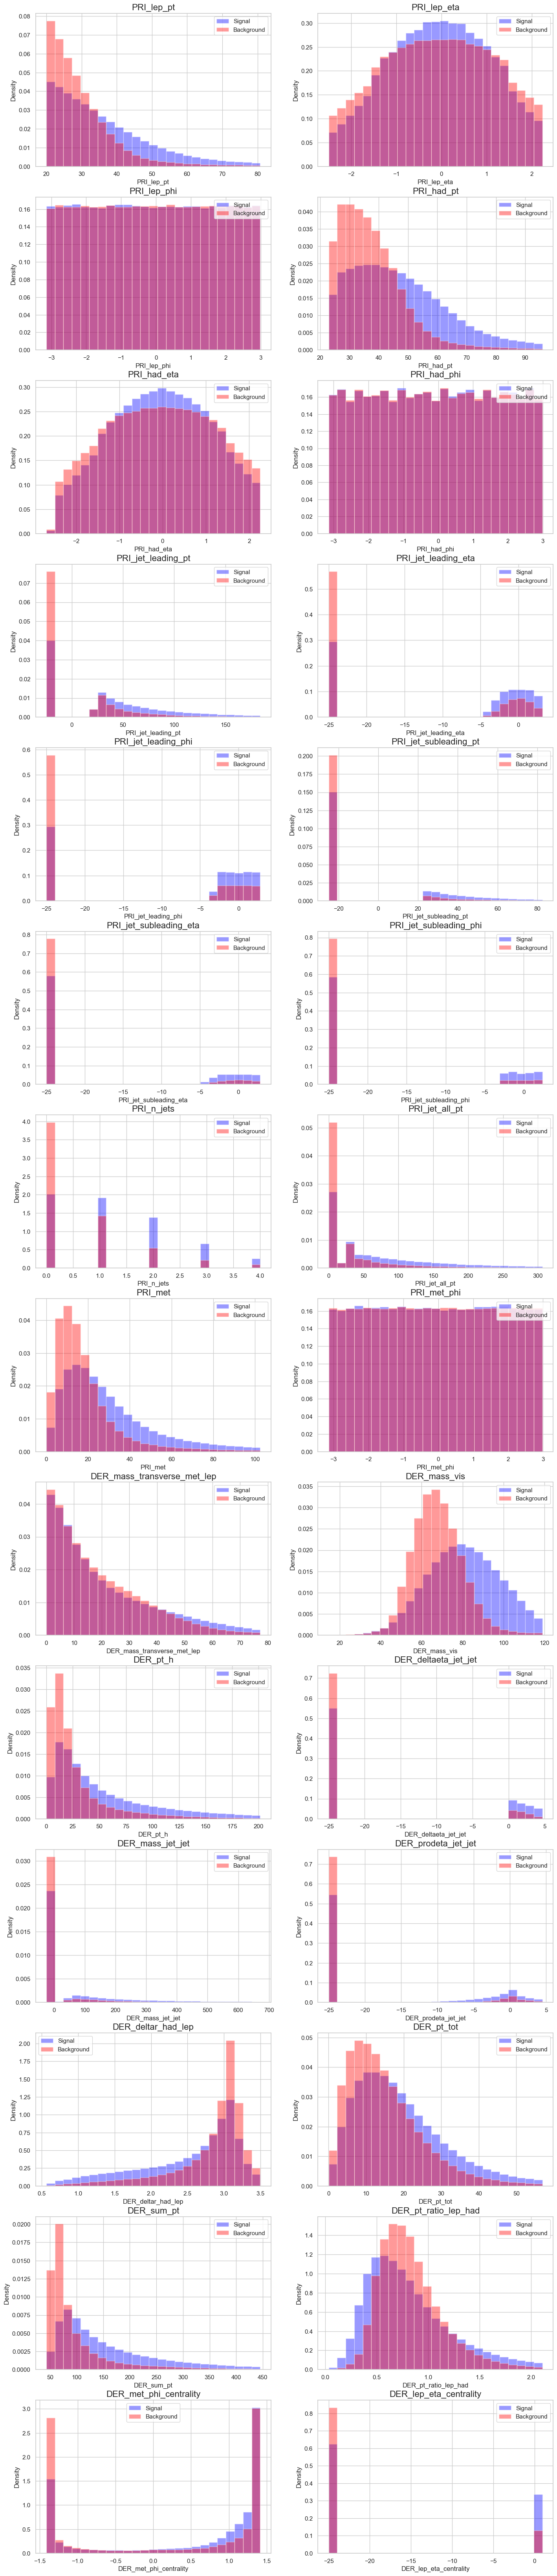

In [ ]:
from utils import histogram_dataset

# this function is defined in utils.py in the sample_code_submission directory. feel free to modify it as needed

histogram_dataset(
    data_set,
    target,
    weights,
    columns=[
        "PRI_lep_pt",
        "PRI_lep_eta",
        "PRI_lep_phi",
        "PRI_had_pt",
        "PRI_had_eta",
        "PRI_had_phi",
        "PRI_jet_leading_pt",
        "PRI_jet_leading_eta",
        "PRI_jet_leading_phi",
        "PRI_jet_subleading_pt",
        "PRI_jet_subleading_eta",
        "PRI_jet_subleading_phi",
        "PRI_n_jets",
        "PRI_jet_all_pt",
        "PRI_met",
        "PRI_met_phi",
        "DER_mass_transverse_met_lep",
        "DER_mass_vis",
        "DER_pt_h",
        "DER_deltaeta_jet_jet",
        "DER_mass_jet_jet",
        "DER_prodeta_jet_jet",
        "DER_deltar_had_lep",
        "DER_pt_tot",
        "DER_sum_pt",
        "DER_pt_ratio_lep_had",
        "DER_met_phi_centrality",
        "DER_lep_eta_centrality",
    ],
)

Signal feature  correlation matrix


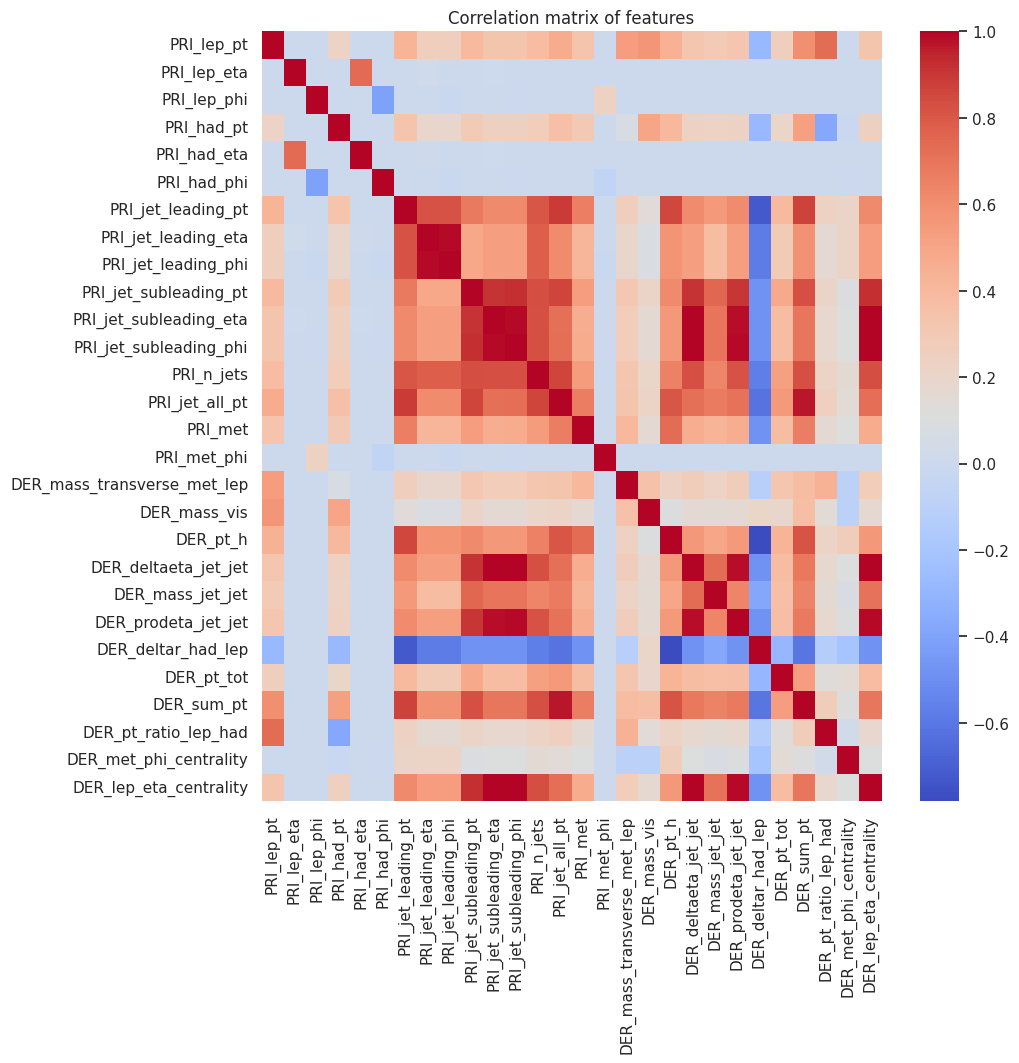

Background feature  correlation matrix


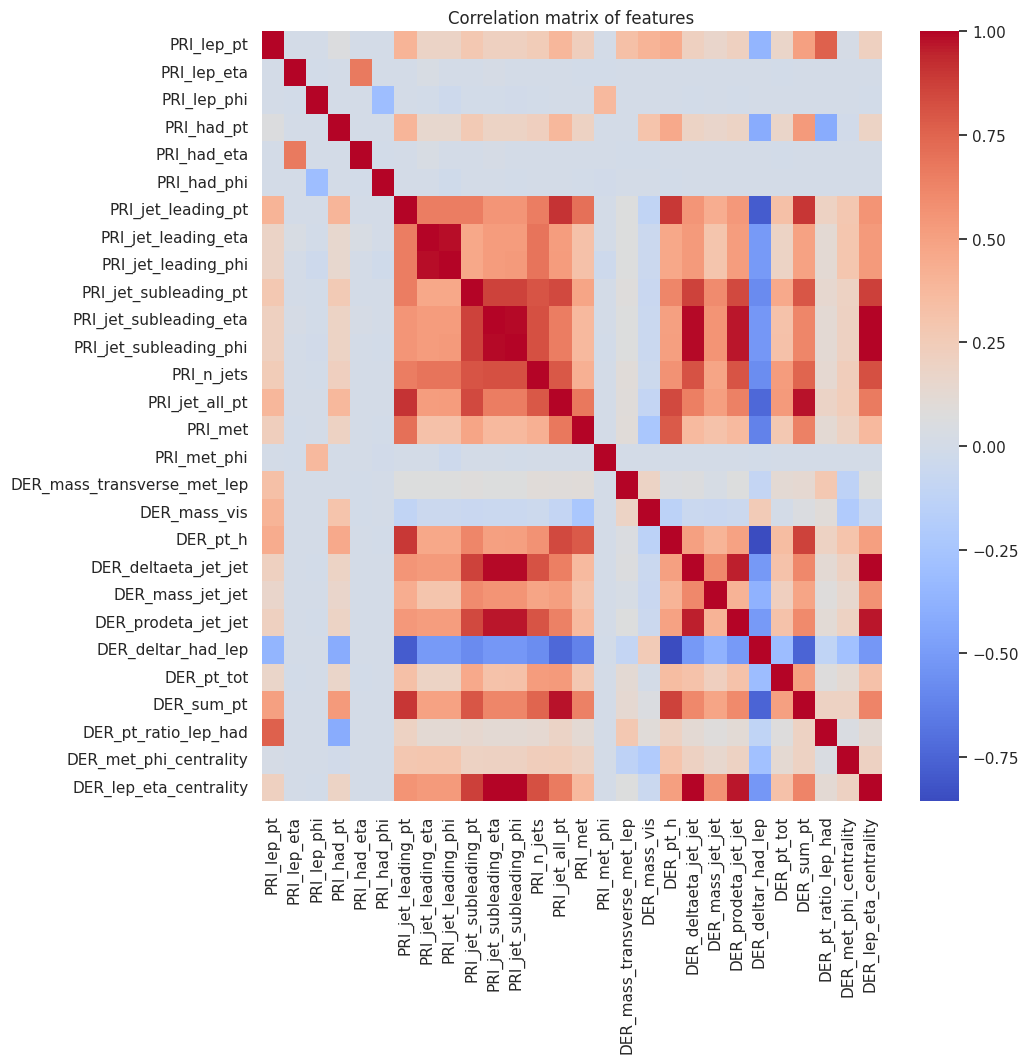

In [19]:
import seaborn as sns

sns.set_theme(rc={"figure.figsize": (10, 10)}, style="whitegrid")

caption = ["Signal feature", "Background feature"]

for i in range(2):

    dfplot = pd.DataFrame(
        data_set,
        columns=[
            "PRI_lep_pt",
            "PRI_lep_eta",
            "PRI_lep_phi",
            "PRI_had_pt",
            "PRI_had_eta",
            "PRI_had_phi",
            "PRI_jet_leading_pt",
            "PRI_jet_leading_eta",
            "PRI_jet_leading_phi",
            "PRI_jet_subleading_pt",
            "PRI_jet_subleading_eta",
            "PRI_jet_subleading_phi",
            "PRI_n_jets",
            "PRI_jet_all_pt",
            "PRI_met",
            "PRI_met_phi",
            "DER_mass_transverse_met_lep",
            "DER_mass_vis",
            "DER_pt_h",
            "DER_deltaeta_jet_jet",
            "DER_mass_jet_jet",
            "DER_prodeta_jet_jet",
            "DER_deltar_had_lep",
            "DER_pt_tot",
            "DER_sum_pt",
            "DER_pt_ratio_lep_had",
            "DER_met_phi_centrality",
            "DER_lep_eta_centrality",
        ],
    )

    print(caption[i], " correlation matrix")
    corrMatrix = dfplot[target == i].corr()
    sns.heatmap(corrMatrix, annot=False, cmap="coolwarm")  # Added cmap='coolwarm'
    plt.title("Correlation matrix of features")
    plt.show()

del dfplot

### Feature Overlap Analysis

This section calculates the overlap between the signal and background distributions for each feature. A higher overlap score indicates that the signal and background distributions for a given feature are more similar, suggesting that the feature is less effective at distinguishing between signal and background events. Conversely, a lower overlap score implies better separation power.

To calculate the overlap:
1.  Histograms for signal and background events are generated for each feature using common bin edges.
2.  These histograms are normalized to represent probability density functions (PDFs).
3.  The overlap is computed as the integral of the minimum of the two normalized PDFs, which corresponds to the area where the two distributions intersect.

Overlap scores (higher means more overlap, sorted descending):



,0
PRI_met_phi,0.994720
PRI_had_phi,0.994440
PRI_lep_phi,0.994308
DER_mass_transverse_met_lep,0.951066
PRI_had_eta,0.944244
PRI_lep_eta,0.940697
DER_pt_tot,0.842852
DER_met_phi_centrality,0.824238
DER_pt_ratio_lep_had,0.812125
DER_mass_jet_jet,0.802459


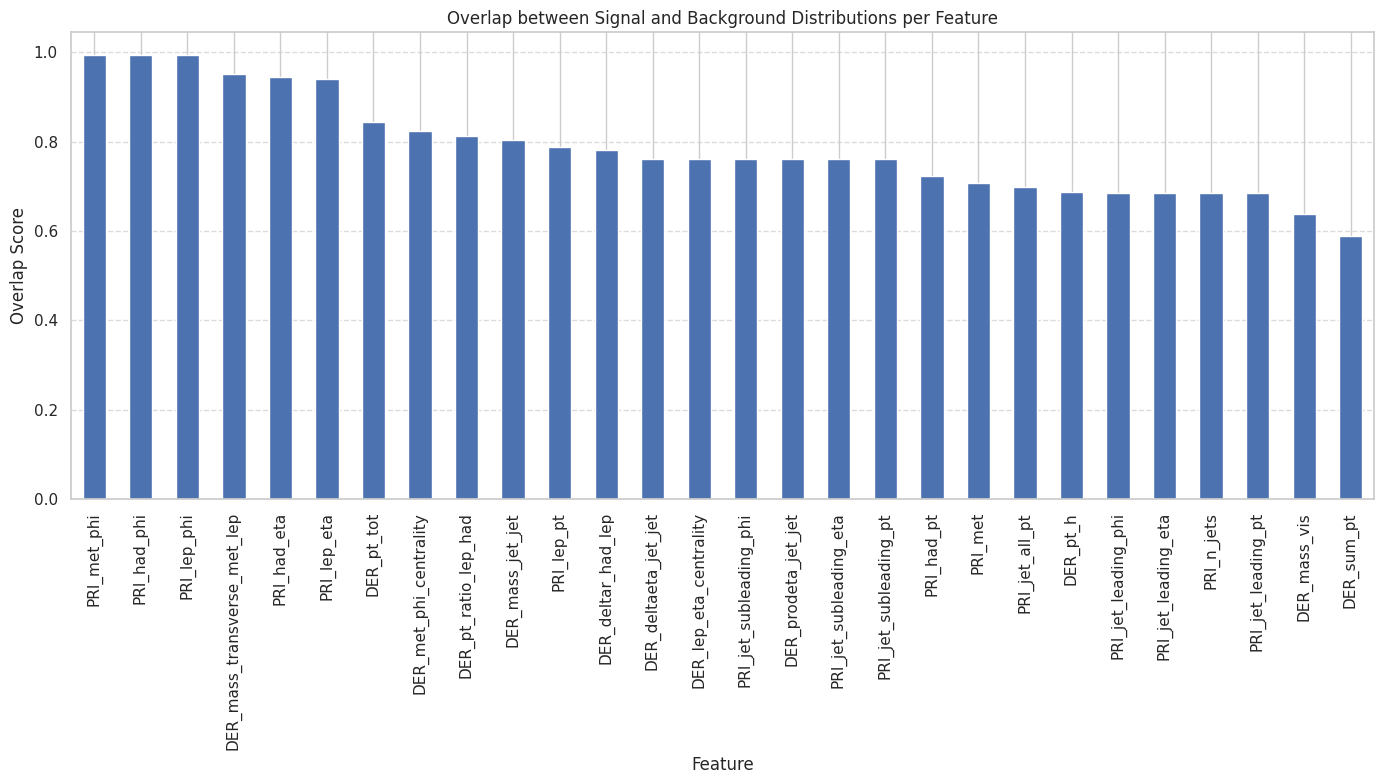

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the list of feature columns for which to calculate overlap
# 'weights' is excluded as it's an event attribute, not a feature for discrimination
feature_columns = [
    "PRI_lep_pt",
    "PRI_lep_eta",
    "PRI_lep_phi",
    "PRI_had_pt",
    "PRI_had_eta",
    "PRI_had_phi",
    "PRI_jet_leading_pt",
    "PRI_jet_leading_eta",
    "PRI_jet_leading_phi",
    "PRI_jet_subleading_pt",
    "PRI_jet_subleading_eta",
    "PRI_jet_subleading_phi",
    "PRI_n_jets",
    "PRI_jet_all_pt",
    "PRI_met",
    "PRI_met_phi",
    "DER_mass_transverse_met_lep",
    "DER_mass_vis",
    "DER_pt_h",
    "DER_deltaeta_jet_jet",
    "DER_mass_jet_jet",
    "DER_prodeta_jet_jet",
    "DER_deltar_had_lep",
    "DER_pt_tot",
    "DER_sum_pt",
    "DER_pt_ratio_lep_had",
    "DER_met_phi_centrality",
    "DER_lep_eta_centrality",
]

# Separate signal and background data based on the 'target' array
signal_indices = target == 1
background_indices = target == 0

overlap_scores = {}
num_bins = 50  # Number of bins for the histograms

for feature in feature_columns:
    # Get signal and background data for the current feature
    signal_data = data_set[feature][signal_indices]
    background_data = data_set[feature][background_indices]

    # Get corresponding weights
    signal_weights = weights[signal_indices]
    background_weights = weights[background_indices]

    # Determine common bin edges for both signal and background to ensure consistent comparison
    min_val = min(np.min(signal_data), np.min(background_data))
    max_val = max(np.max(signal_data), np.max(background_data))
    bins = np.linspace(min_val, max_val, num_bins + 1)

    # Create normalized histograms (PDFs) for signal and background
    # density=True normalizes the histogram so that the integral over the range is 1
    hist_signal, _ = np.histogram(
        signal_data, bins=bins, weights=signal_weights, density=True
    )
    hist_background, _ = np.histogram(
        background_data, bins=bins, weights=background_weights, density=True
    )

    # Calculate bin width
    bin_width = bins[1] - bins[0]

    # Calculate overlap: sum of the minimum of the two PDFs multiplied by bin_width
    # This represents the area where the two distributions intersect
    overlap = np.sum(np.minimum(hist_signal, hist_background)) * bin_width
    overlap_scores[feature] = overlap

# Convert to a Pandas Series for better display and sorting
overlap_scores_series = pd.Series(overlap_scores)
overlap_scores_sorted = overlap_scores_series.sort_values(ascending=False)

print("Overlap scores (higher means more overlap, sorted descending):\n")
display(overlap_scores_sorted)

# Plotting the overlaps for better visualization
plt.figure(figsize=(14, 8))
overlap_scores_sorted.plot(kind="bar")
plt.title("Overlap between Signal and Background Distributions per Feature")
plt.xlabel("Feature")
plt.ylabel("Overlap Score")
plt.xticks(rotation=90)  # Rotate labels for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

### Stacked Histograms for All Features

Below are stacked histograms for each individual feature, illustrating the distribution of signal (htautau) and various background components (diboson, ttbar, ztautau). These plots are crucial for understanding how well each feature can discriminate between signal and background events. Features with distinct signal and background shapes are generally more useful for classification tasks.

Generating stacked histogram for: PRI_lep_pt
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


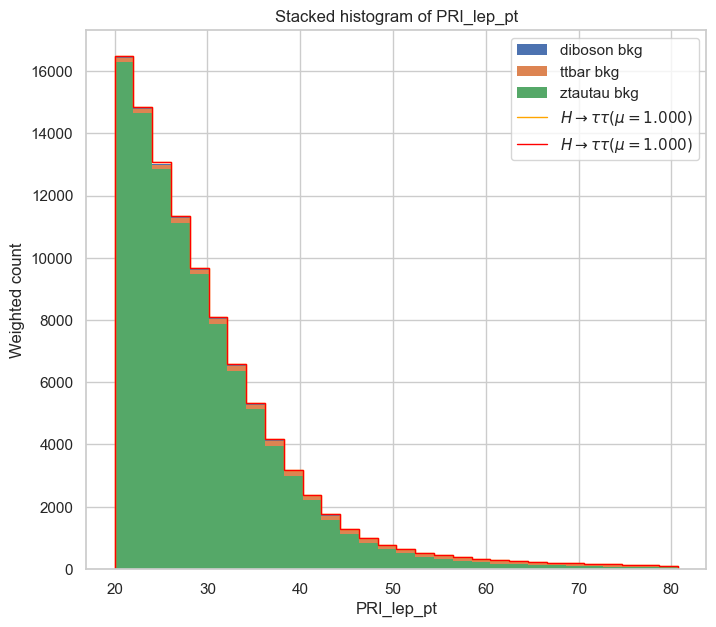

Generating stacked histogram for: PRI_lep_eta
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


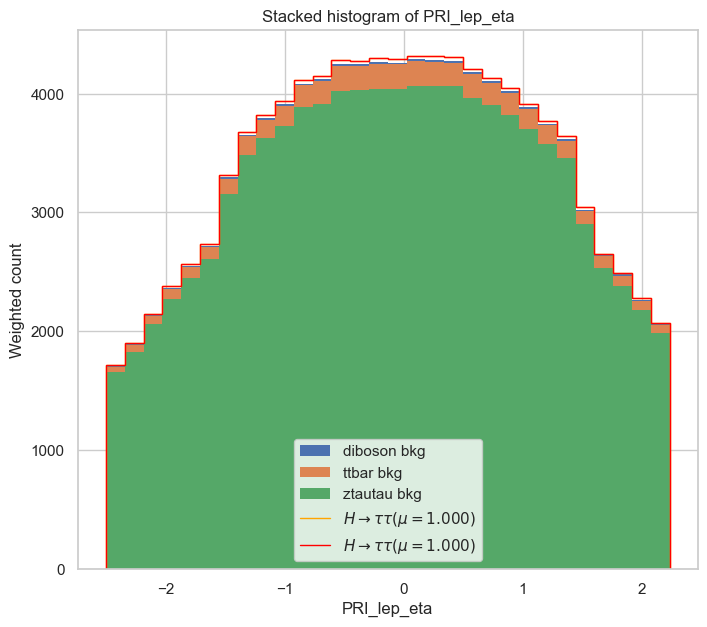

Generating stacked histogram for: PRI_lep_phi
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


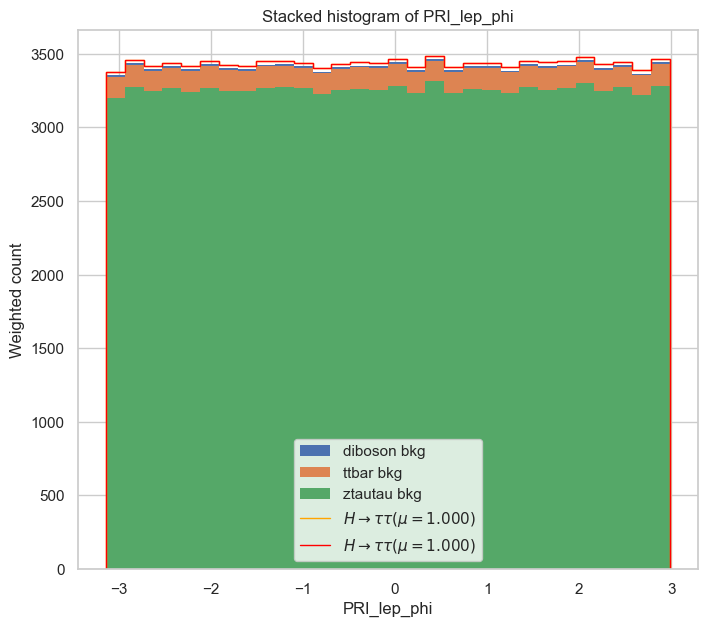

Generating stacked histogram for: PRI_had_pt
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


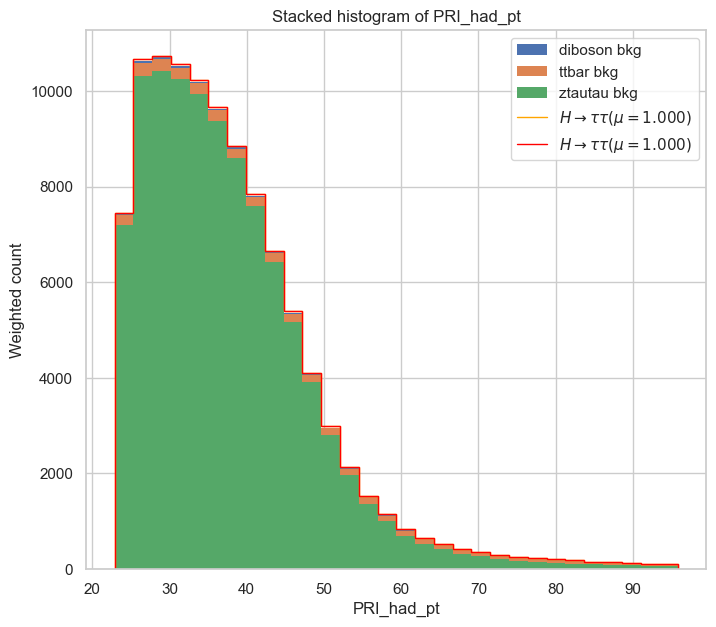

Generating stacked histogram for: PRI_had_eta
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


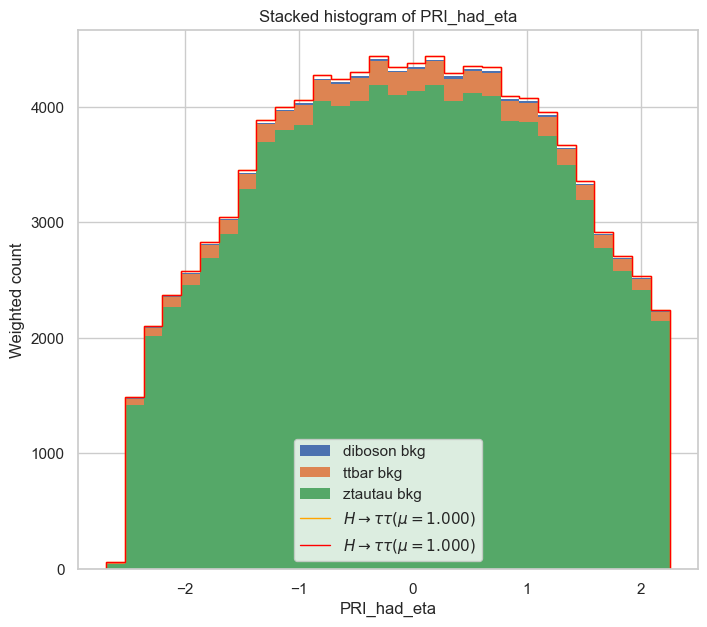

Generating stacked histogram for: PRI_had_phi
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


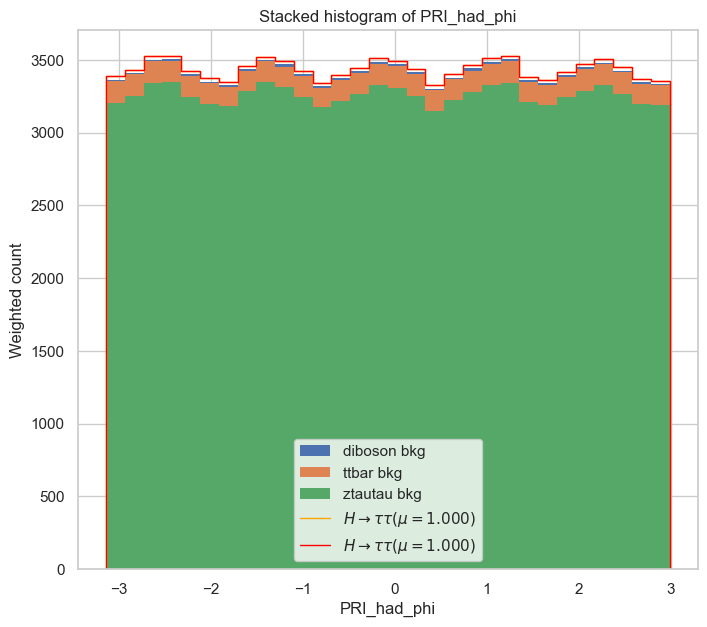

Generating stacked histogram for: PRI_jet_leading_pt
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


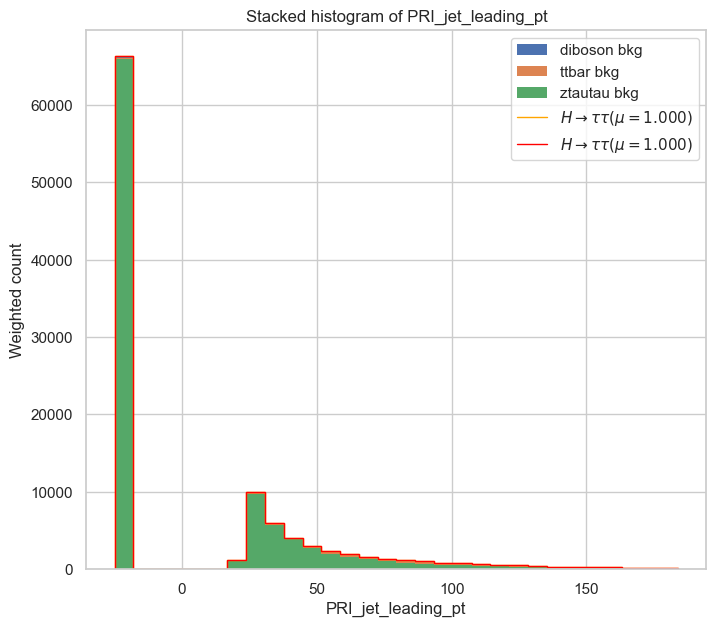

Generating stacked histogram for: PRI_jet_leading_eta
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


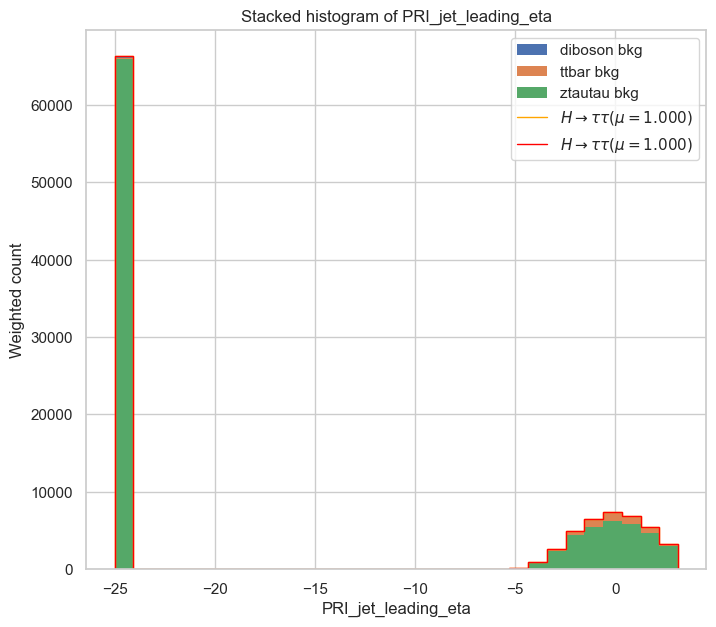

Generating stacked histogram for: PRI_jet_leading_phi
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


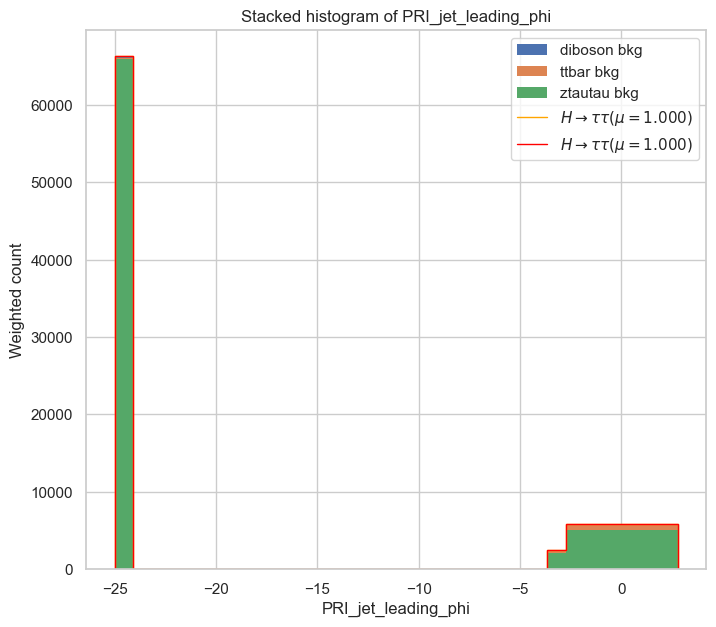

Generating stacked histogram for: PRI_jet_subleading_pt
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


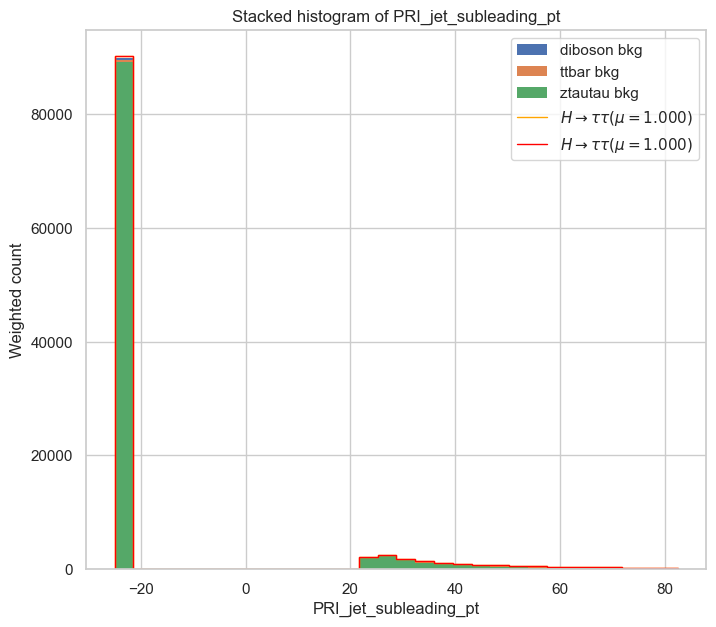

Generating stacked histogram for: PRI_jet_subleading_eta
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


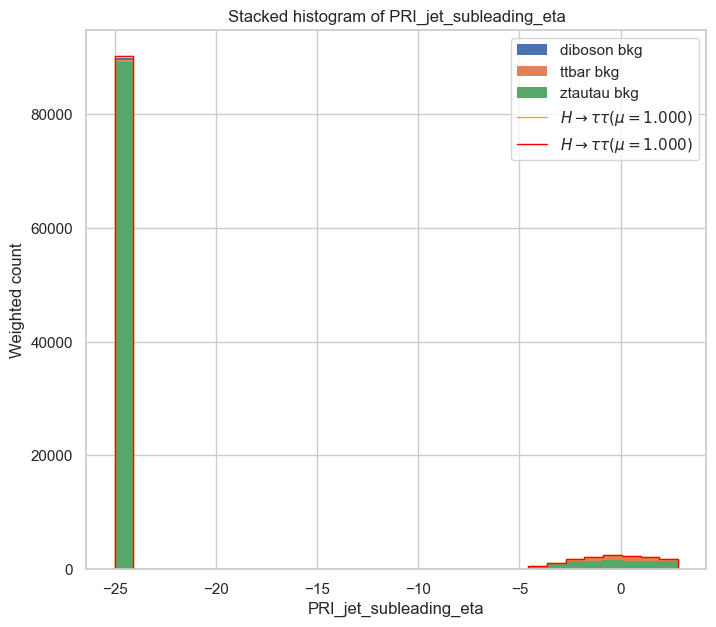

Generating stacked histogram for: PRI_jet_subleading_phi
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


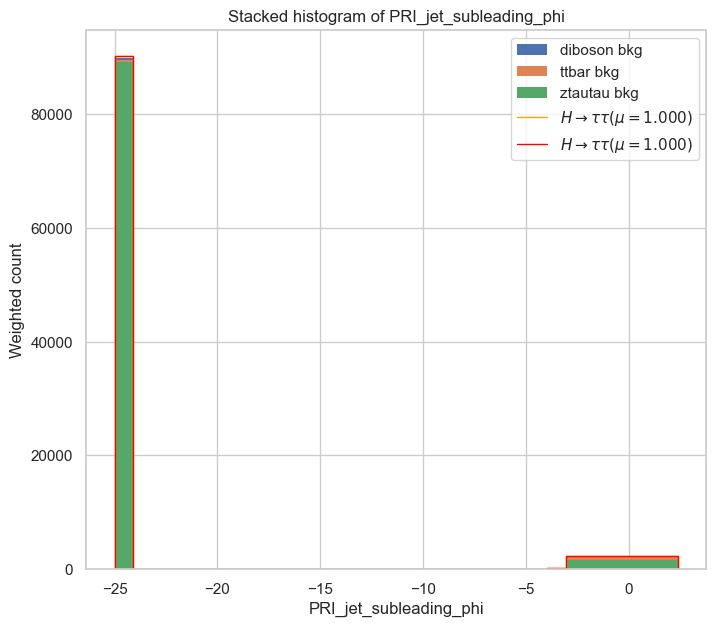

Generating stacked histogram for: PRI_n_jets
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


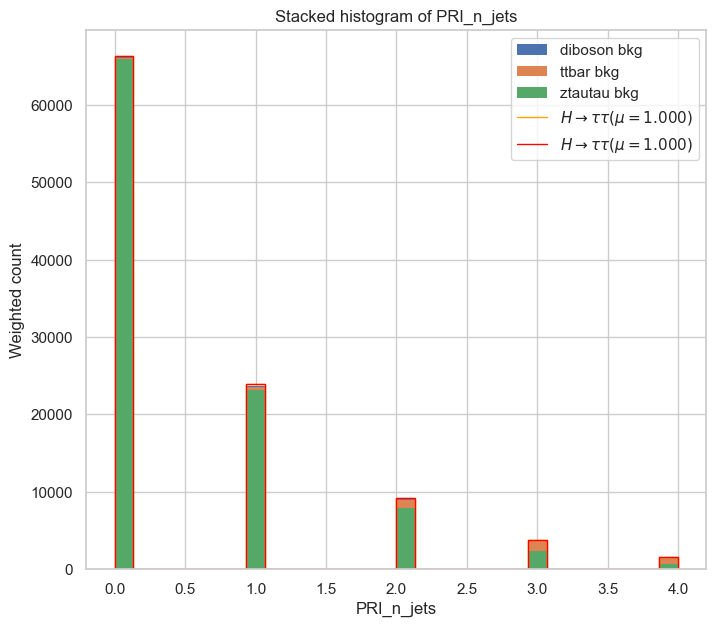

Generating stacked histogram for: PRI_jet_all_pt
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


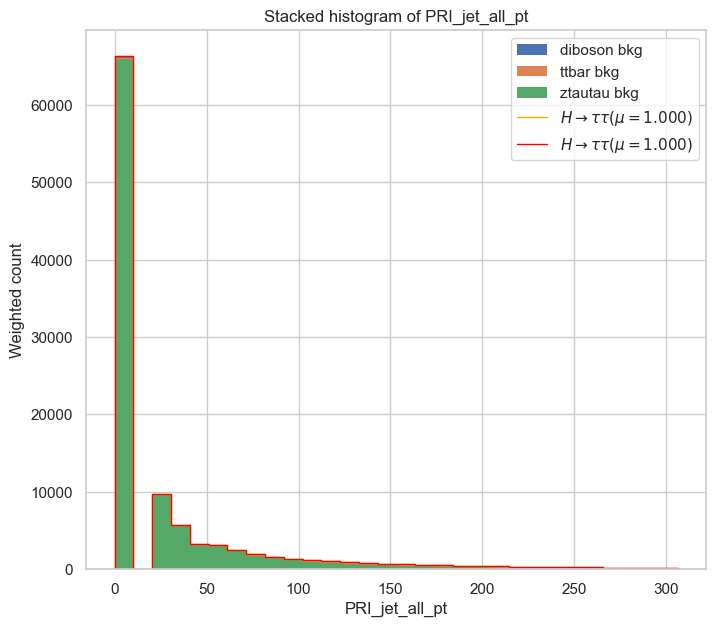

Generating stacked histogram for: PRI_met
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


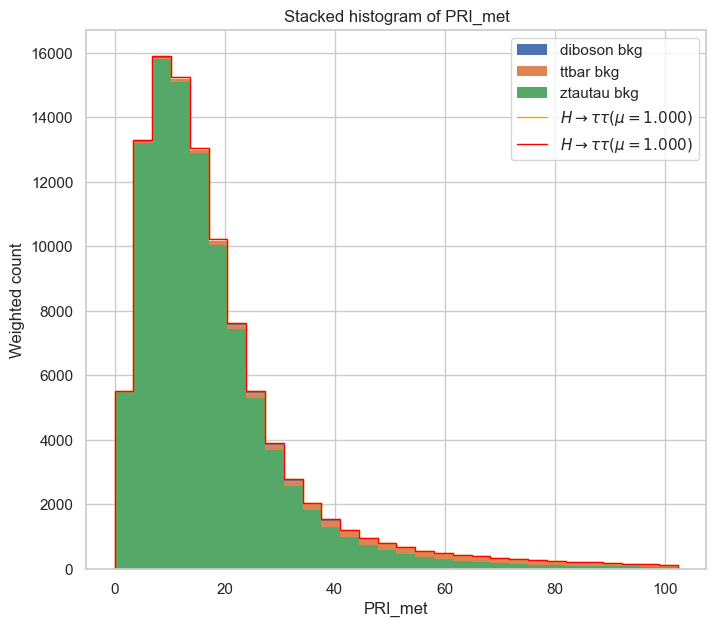

Generating stacked histogram for: PRI_met_phi
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


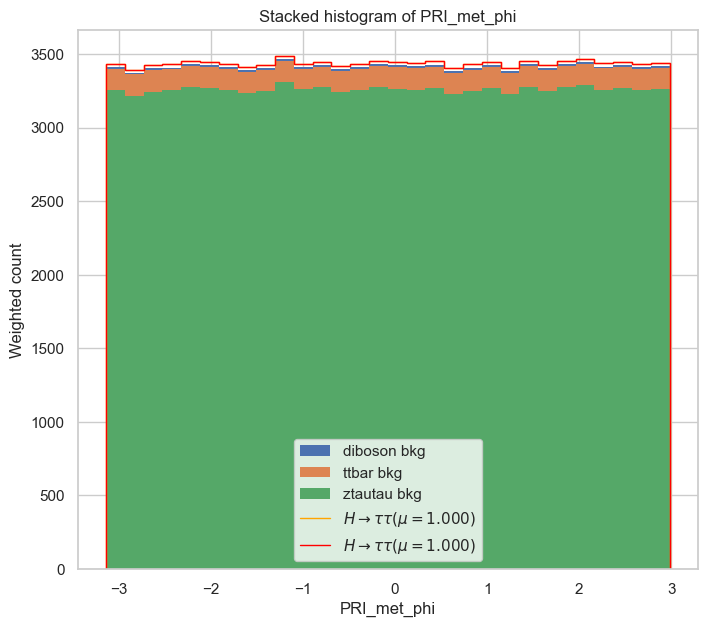

Generating stacked histogram for: DER_mass_transverse_met_lep
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


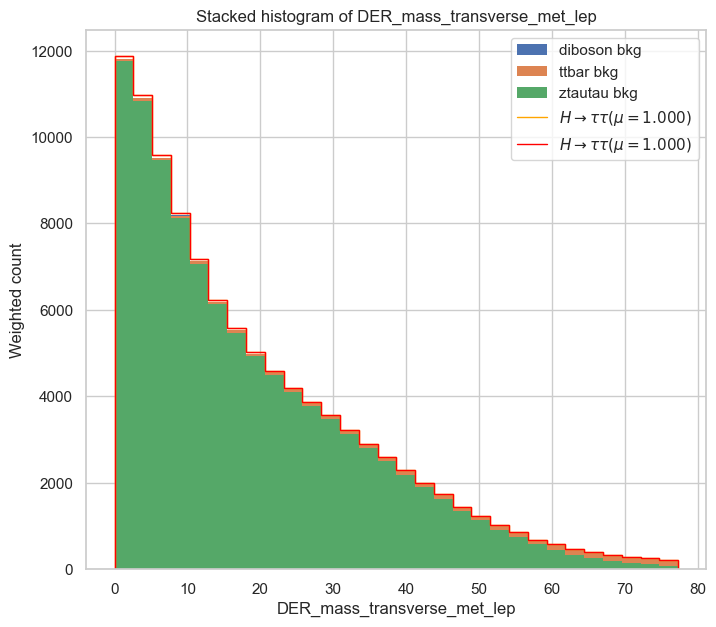

Generating stacked histogram for: DER_mass_vis
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


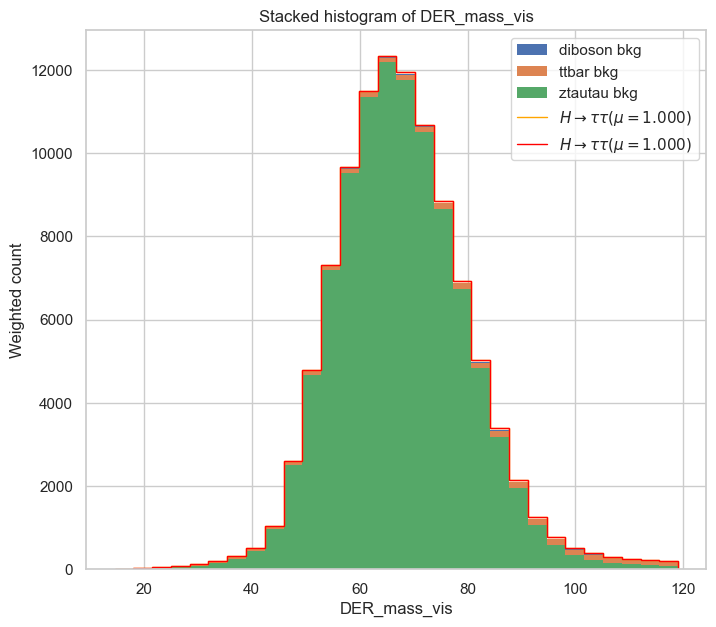

Generating stacked histogram for: DER_pt_h
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


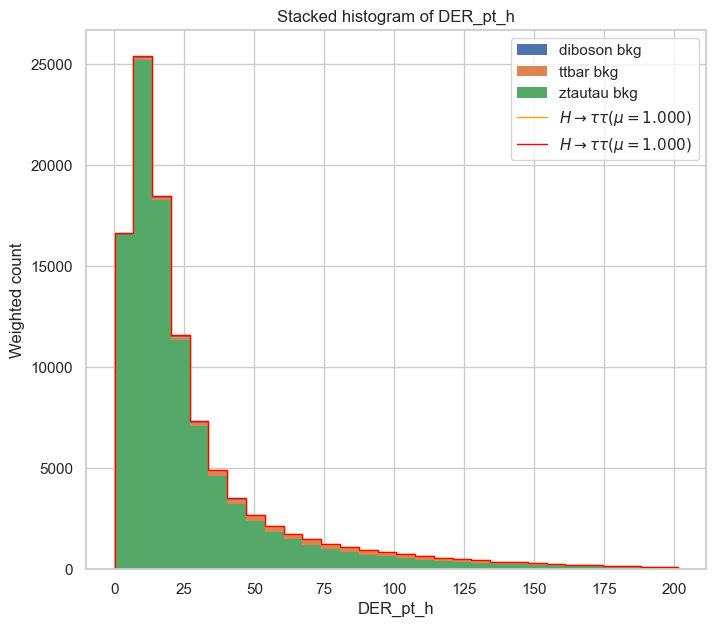

Generating stacked histogram for: DER_deltaeta_jet_jet
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


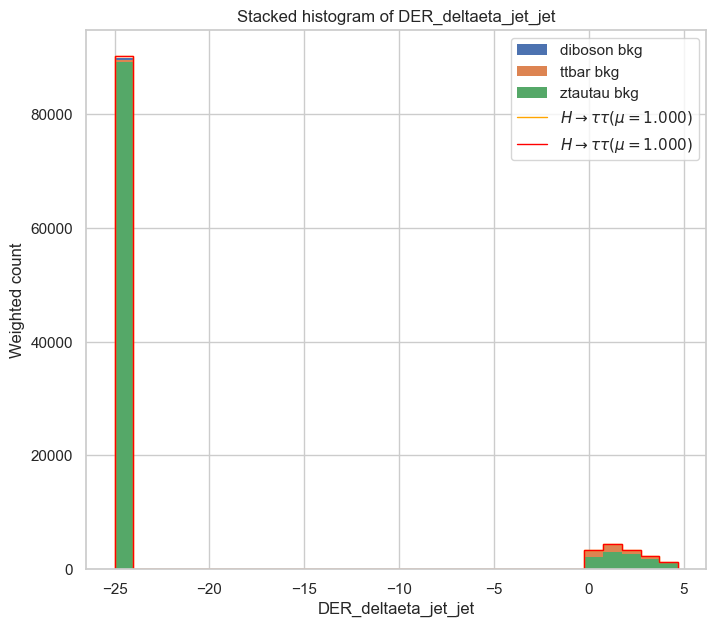

Generating stacked histogram for: DER_mass_jet_jet
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


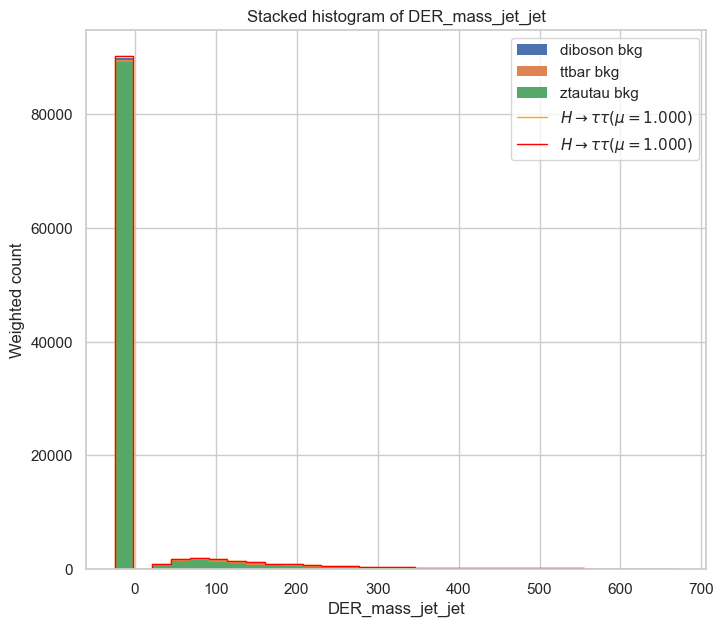

Generating stacked histogram for: DER_prodeta_jet_jet
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


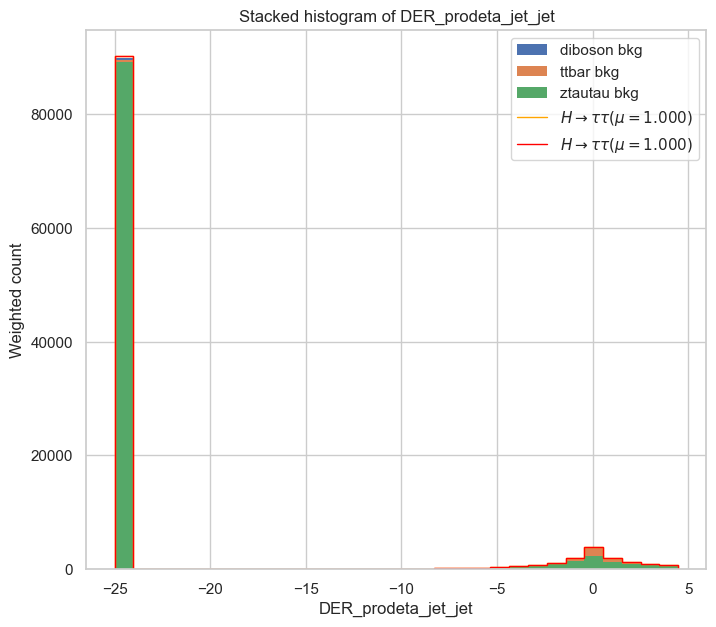

Generating stacked histogram for: DER_deltar_had_lep
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


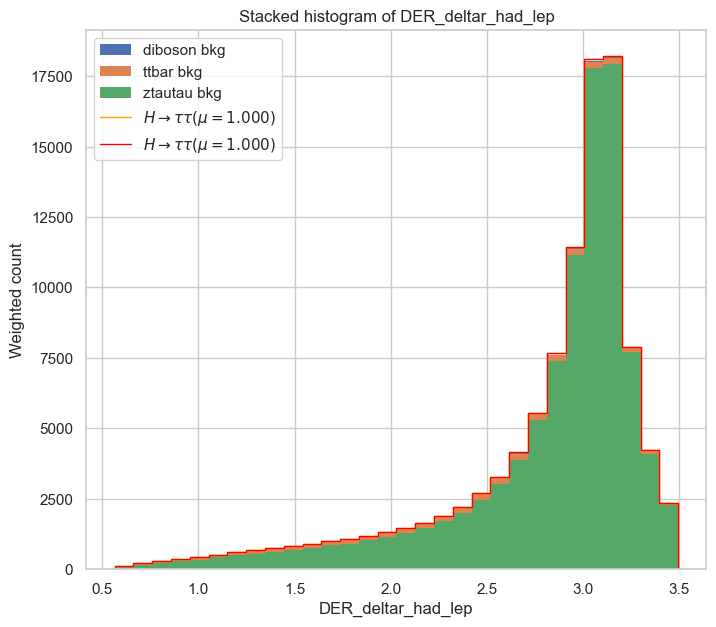

Generating stacked histogram for: DER_pt_tot
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


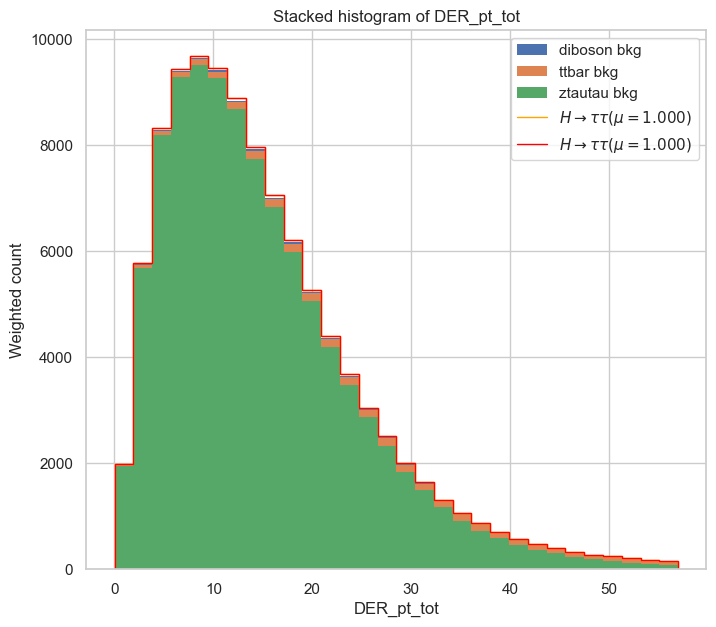

Generating stacked histogram for: DER_sum_pt
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


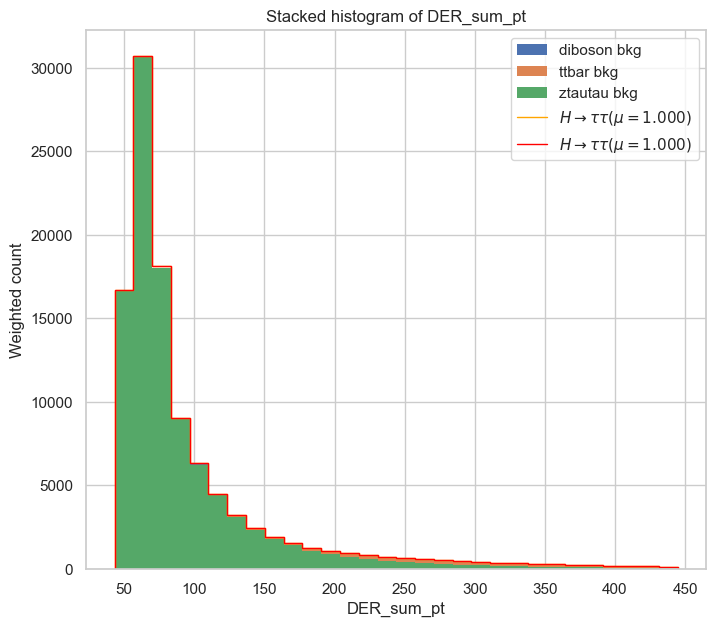

Generating stacked histogram for: DER_pt_ratio_lep_had
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


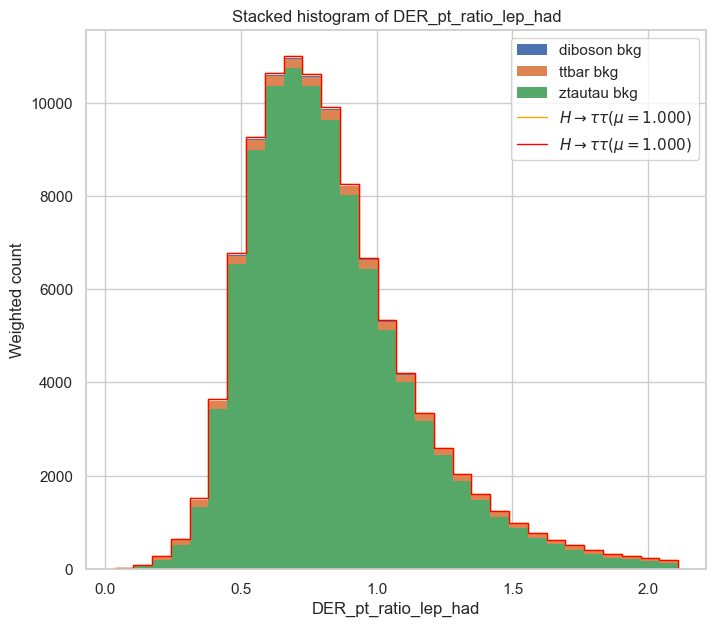

Generating stacked histogram for: DER_met_phi_centrality
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


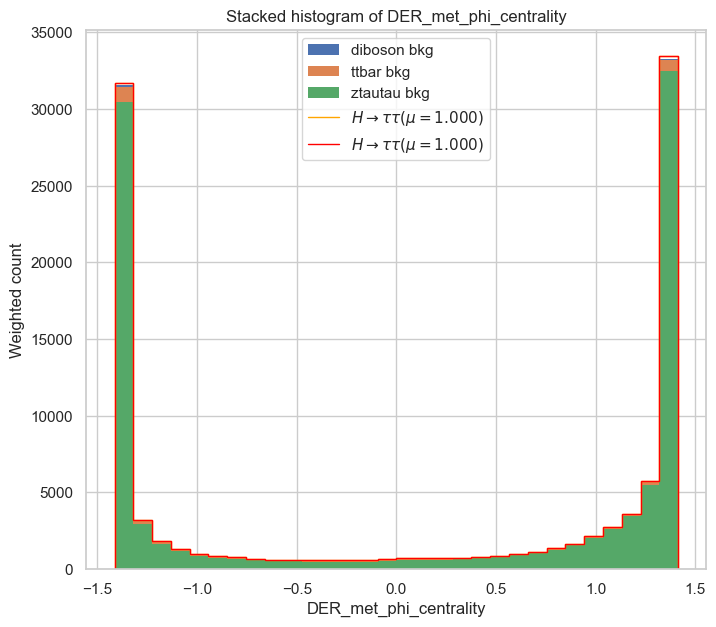

Generating stacked histogram for: DER_lep_eta_centrality
keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


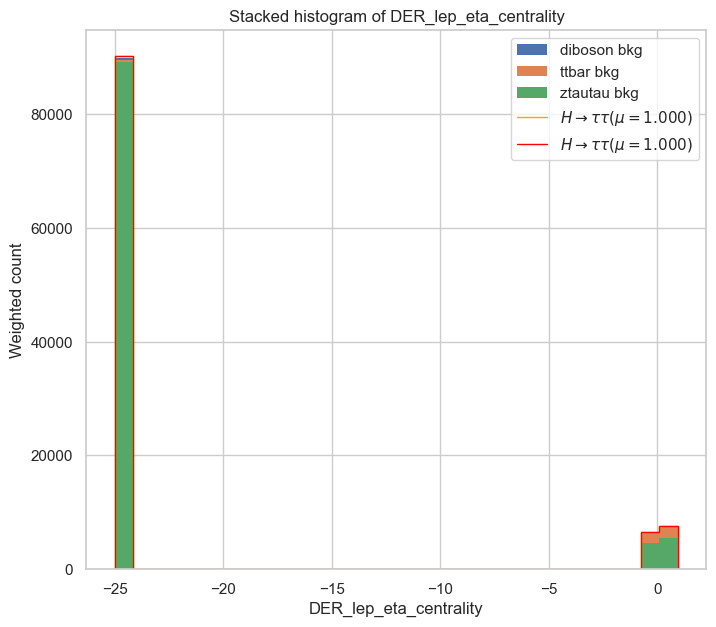

In [ ]:
from HiggsML.visualization import stacked_histogram

# Define the list of feature columns, excluding 'weights' as it's not a physical feature
feature_columns = [
    "PRI_lep_pt",
    "PRI_lep_eta",
    "PRI_lep_phi",
    "PRI_had_pt",
    "PRI_had_eta",
    "PRI_had_phi",
    "PRI_jet_leading_pt",
    "PRI_jet_leading_eta",
    "PRI_jet_leading_phi",
    "PRI_jet_subleading_pt",
    "PRI_jet_subleading_eta",
    "PRI_jet_subleading_phi",
    "PRI_n_jets",
    "PRI_jet_all_pt",
    "PRI_met",
    "PRI_met_phi",
    "DER_mass_transverse_met_lep",
    "DER_mass_vis",
    "DER_pt_h",
    "DER_deltaeta_jet_jet",
    "DER_mass_jet_jet",
    "DER_prodeta_jet_jet",
    "DER_deltar_had_lep",
    "DER_pt_tot",
    "DER_sum_pt",
    "DER_pt_ratio_lep_had",
    "DER_met_phi_centrality",
    "DER_lep_eta_centrality",
]

for feature in feature_columns:
    print(f"Generating stacked histogram for: {feature}")
    stacked_histogram(data_set, target, weights, detailed_label, feature)

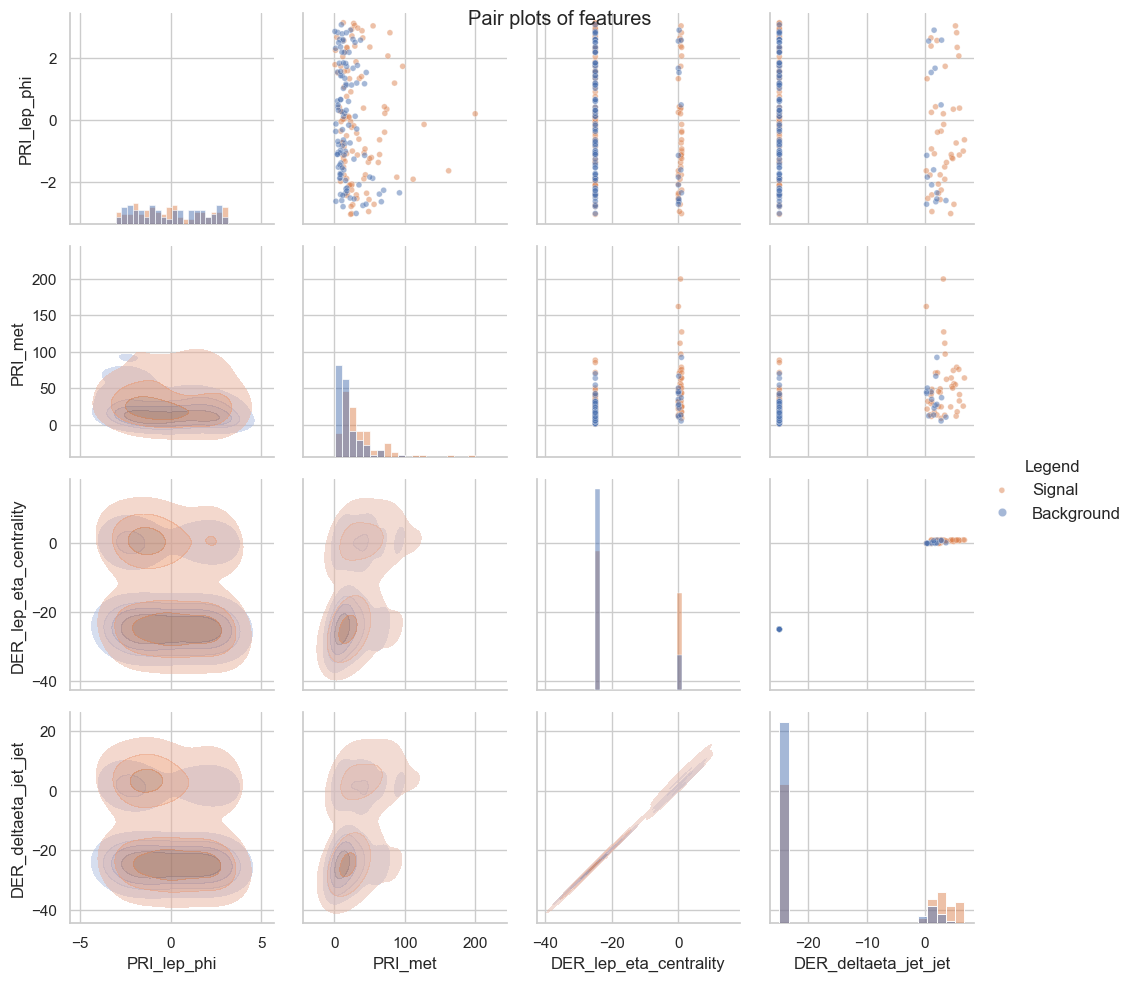

In [ ]:
from HiggsML.visualization import pair_plots

# Show data summary
pair_plots(
    data_set,
    target,
    sample_size=100,
    columns=[
        "PRI_lep_phi",
        "PRI_met",
        "DER_lep_eta_centrality",
        "DER_deltaeta_jet_jet",
    ],
)

### Ingestion



In [22]:
from HiggsML.ingestion import Ingestion

ingestion = Ingestion(data)

In [23]:
# initialize submission
ingestion.init_submission(Model, "BDT")

Training Data:  (5000, 28)
Training Labels:  (5000,)
Training Weights:  (5000,)
sum_signal_weights:  674.9480134593748
sum_bkg_weights:  105044.05198654061

Valid Data:  (5000, 28)
Valid Labels:  (5000,)
Valid Weights:  (5000,)
sum_signal_weights:  663.5700617478653
sum_bkg_weights:  105055.42993825214

Holdout Data:  (5000, 28)
Holdout Labels:  (5000,)
Holdout Weights:  (5000,)
sum_signal_weights:  662.8612616691523
sum_bkg_weights:  105056.13873833085
 
 
Training Data:  (5000, 28)
DEBUG: model_type = 'BDT'
 Model is BDT


score shape before threshold (4558,)
score shape after threshold (4558,)
saved_info {'beta': np.float64(13759.371717883841), 'gamma': np.float64(432.0923085901273), 'tes_fit': <function tes_fitter.<locals>.fit_function at 0x7ca9783ee480>, 'jes_fit': <function jes_fitter.<locals>.fit_function at 0x7ca96771cf40>}
Train Results: 
	 mu_hat  :  -29.80821790633664
	 del_mu_stat  :  0.27570018946513786
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27570018946513786
Holdout Results: 
	 mu_hat  :  1.000000000000003
	 del_mu_stat  :  0.27570018946513786
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27570018946513786
Valid Results: 
	 mu_hat  :  3.252024099476464
	 del_mu_stat  :  0.27570018946513786
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27570018946513786
[*] --- score histogram


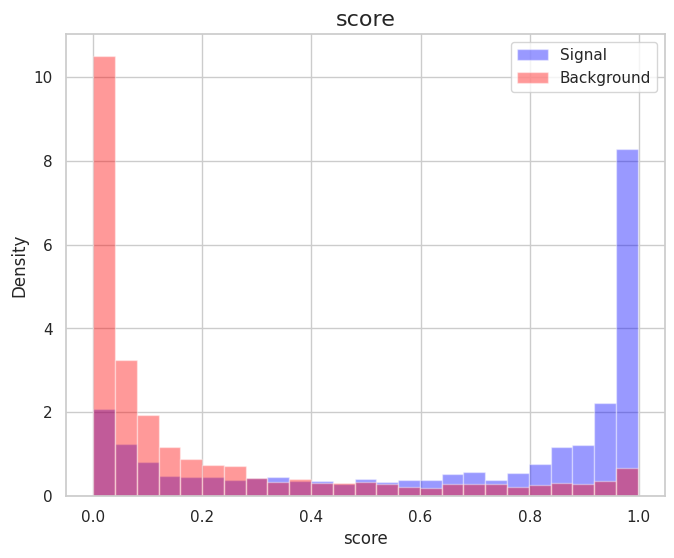

keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


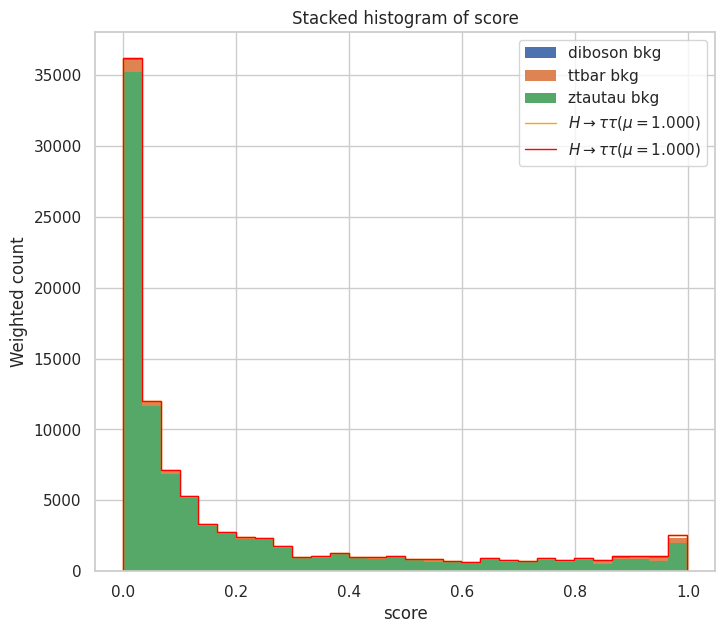

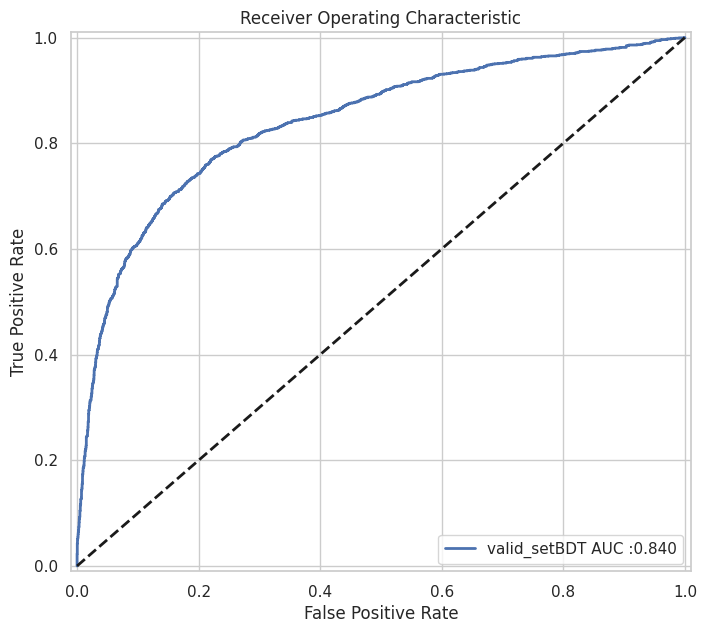

In [24]:
# fit submission
ingestion.fit_submission()

In [ ]:
# load test set
data.load_test_set()

2026-06-03 14:40:17,898 - HiggsML.datasets     - INFO     - Data loaded successfully
2026-06-03 14:40:18,560 - HiggsML.datasets     - INFO     - Test data loaded successfully


### Test Settings
The Test setting sets the test conditions in ingestion.
This includes what systematics you want and how many psuedo experiments you want.

In [ ]:
test_settings = {
    "systematics": {  # Systematics to use
        "tes": False,  # tau energy scale
        "jes": False,  # jet energy scale
        "soft_met": False,  # soft term in MET
        "ttbar_scale": False,  # W boson scale factor
        "diboson_scale": False,  # Diboson scale factor
        "bkg_scale": False,  # Background scale factor
    },
    "num_pseudo_experiments": 500,  # Number of pseudo-experiments to run per set
    "num_of_sets": 1,  # Number of sets of pseudo-experiments to run
}

RANDOM_SEED = 42

random_state = np.random.RandomState(RANDOM_SEED)
test_settings["ground_truth_mus"] = (
    random_state.uniform(0.1, 3, test_settings["num_of_sets"])
).tolist()

random_settings_file = os.path.join(output_dir, "test_settings.json")
with open(random_settings_file, "w") as f:
    json.dump(test_settings, f)

In [ ]:
# predict submission
ingestion.predict_submission(test_settings)

2026-06-03 14:40:50,578 - HiggsML.ingestion    - INFO     - Calling predict method of submitted model with seed: 31415


Test Results:  {'mu_hat': np.float64(2.3712523827437484), 'del_mu_stat': np.float64(0.2587416873684586), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.2587416873684586)}
Test Results:  {'mu_hat': np.float64(2.517945406539054), 'del_mu_stat': np.float64(0.2587416873684586), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.2587416873684586)}
Test Results:  {'mu_hat': np.float64(1.7506280513020713), 'del_mu_stat': np.float64(0.2587416873684586), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.2587416873684586)}
Test Results:  {'mu_hat': np.float64(2.222302543197746), 'del_mu_stat': np.float64(0.2587416873684586), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.2587416873684586)}
Test Results:  {'mu_hat': np.float64(2.811331454129665), 'del_mu_stat': np.float64(0.2587416873684586), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.2587416873684586)}
Test Results:  {'mu_hat': np.float64(2.260668410959595), 'del_mu_stat': np.float64(0.25874168

In [ ]:
ingestion.process_results_dict()

In [ ]:
# save result
ingestion.save_result(output_dir)

## Score
1. Compute Scores
2. Visualize Scores


In [ ]:
from HiggsML.score import Scoring

In [ ]:
# Initialize Score
score = Scoring()

In [ ]:
print(output_dir)
score.load_ingestion_results(prediction_dir=output_dir, score_dir=output_dir)

2026-06-03 14:46:23,803 - HiggsML.score        - INFO     - Read ingestion results from c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission


c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission


2026-06-03 14:46:30,104 - HiggsML.score        - INFO     - Computing scores


[✔]


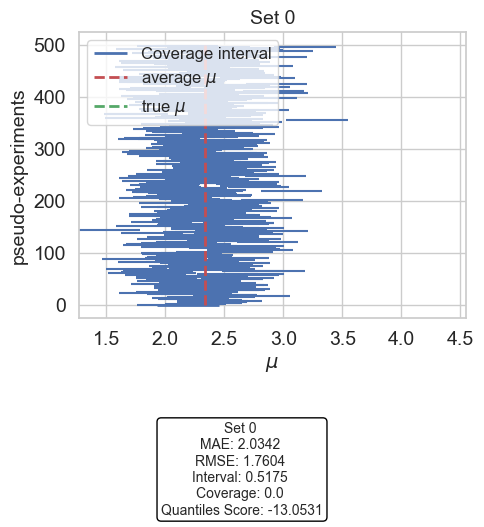

In [ ]:
# Compute Score
score.compute_scores(test_settings)

### Feature Importance Analysis

This section calculates and visualizes the importance of each feature in distinguishing between signal and background, using the BDT trained by the ingestion pipeline.

Training XGBoost model to get feature importances...
XGBoost model training complete.

Feature Importances (sorted descending):



DER_sum_pt                     0.181825
DER_mass_vis                   0.166144
DER_mass_jet_jet               0.114224
PRI_met                        0.096931
DER_mass_transverse_met_lep    0.059529
DER_met_phi_centrality         0.044396
PRI_had_pt                     0.037369
DER_lep_eta_centrality         0.035495
PRI_n_jets                     0.029263
DER_deltar_had_lep             0.023440
PRI_jet_leading_eta            0.023439
DER_deltaeta_jet_jet           0.021235
PRI_jet_leading_pt             0.019746
DER_pt_h                       0.019593
DER_pt_ratio_lep_had           0.017711
PRI_lep_eta                    0.016839
PRI_jet_subleading_pt          0.014948
PRI_had_eta                    0.013530
PRI_lep_pt                     0.010976
PRI_jet_all_pt                 0.009418
DER_prodeta_jet_jet            0.008654
PRI_jet_subleading_eta         0.007673
PRI_jet_leading_phi            0.006502
DER_pt_tot                     0.006414
PRI_jet_subleading_phi         0.004611


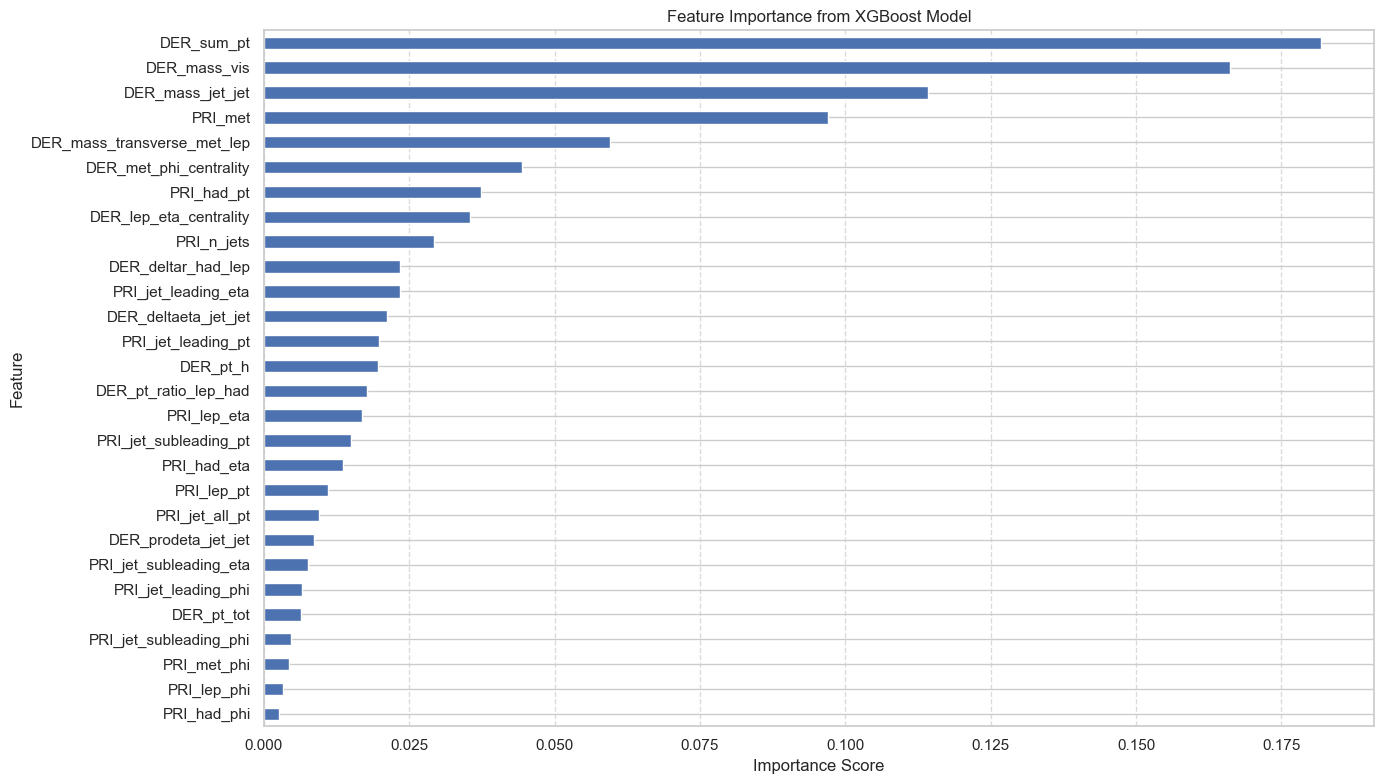

In [ ]:
# Get the trained BDT from the ingestion pipeline
if not hasattr(ingestion, "model"):
    raise AttributeError(
        "Ingestion has no attribute 'model'. Make sure init_submission and fit_submission were run."
    )

model_bdt = ingestion.model

if not hasattr(model_bdt, "model"):
    raise AttributeError(
        "The submitted model does not expose an internal estimator as 'model'."
    )

bst = model_bdt.model
if not hasattr(bst, "feature_importances_"):
    raise AttributeError("The internal model does not provide feature_importances_.")

feature_importances = bst.feature_importances_

# Create a Pandas Series for easy handling and sorting
importance_series = pd.Series(feature_importances, index=feature_columns)
importance_series_sorted = importance_series.sort_values(ascending=False)

print("Feature importances from the ingestion BDT model:\n")
display(importance_series_sorted)

# Plotting the feature importances
plt.figure(figsize=(14, 8))
importance_series_sorted.plot(kind="barh")
plt.title("Feature Importance from Ingestion BDT")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Comparing Feature Importance Before and After Replacing -25 with NaN

The feature importances displayed above were calculated using the dataset **with** the `-25` placeholder values still present. To understand the impact of treating these values as missing data, we will now:

1.  Create a copy of the `data_set` and replace all `-25` values with `np.nan`.
2.  Recalculate the feature importances using this `NaN`-filled dataset.
3.  Compare the new importances with the original ones.

In [21]:
import xgboost as xgb

# Create a copy of the data_set and replace -25 with NaN
data_set_with_nan = data_set.copy()
data_set_with_nan.replace(-25, np.nan, inplace=True)

# Prepare data for XGBoost using the NaN-filled dataset
X_nan = data_set_with_nan[feature_columns]
y_nan = target
sample_weights_nan = weights  # Weights remain the same

# Initialize and train an XGBoost classifier with NaN handling
# XGBoost has built-in NaN handling; by default, missing values are treated as a separate category.
# You can also explicitly set `missing=np.nan` for clarity, though it's often the default.
model_bdt_nan = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,  # Use all available cores
)

print("Training XGBoost model on data with NaNs for feature importances...")
model_bdt_nan.fit(X_nan, y_nan, sample_weight=sample_weights_nan)
print("XGBoost model training complete on NaN-filled data.")

# Get feature importances after NaN replacement
feature_importances_after_nan = model_bdt_nan.feature_importances_
importance_series_after_nan = pd.Series(
    feature_importances_after_nan, index=feature_columns
)
importance_series_after_nan_sorted = importance_series_after_nan.sort_values(
    ascending=False
)

print("\nFeature Importances after replacing -25 with NaN (sorted descending):\n")
display(importance_series_after_nan_sorted)

Training XGBoost model on data with NaNs for feature importances...
XGBoost model training complete on NaN-filled data.

Feature Importances after replacing -25 with NaN (sorted descending):



,0
DER_sum_pt,0.195819
DER_mass_vis,0.167262
PRI_met,0.102189
DER_mass_jet_jet,0.087543
DER_mass_transverse_met_lep,0.062666
DER_met_phi_centrality,0.045367
PRI_had_pt,0.037869
DER_lep_eta_centrality,0.033779
PRI_n_jets,0.030448
PRI_jet_leading_eta,0.026766


In [ ]:
print("Comparison of Feature Importances:\n")
print("--- Before replacing -25 with NaN ---")
display(importance_series_sorted)

print("\n--- After replacing -25 with NaN ---")
display(importance_series_after_nan_sorted)

# Optionally, create a DataFrame for side-by-side comparison
comparison_df = pd.DataFrame(
    {
        "Importance_Before_NaN": importance_series_sorted,
        "Importance_After_NaN": importance_series_after_nan_sorted,
    }
).sort_values(by="Importance_Before_NaN", ascending=False)

print("\nSide-by-side comparison (sorted by importance before NaN replacement):\n")
display(comparison_df)

Comparison of Feature Importances:

--- Before replacing -25 with NaN ---


DER_sum_pt                     0.181825
DER_mass_vis                   0.166144
DER_mass_jet_jet               0.114224
PRI_met                        0.096931
DER_mass_transverse_met_lep    0.059529
DER_met_phi_centrality         0.044396
PRI_had_pt                     0.037369
DER_lep_eta_centrality         0.035495
PRI_n_jets                     0.029263
DER_deltar_had_lep             0.023440
PRI_jet_leading_eta            0.023439
DER_deltaeta_jet_jet           0.021235
PRI_jet_leading_pt             0.019746
DER_pt_h                       0.019593
DER_pt_ratio_lep_had           0.017711
PRI_lep_eta                    0.016839
PRI_jet_subleading_pt          0.014948
PRI_had_eta                    0.013530
PRI_lep_pt                     0.010976
PRI_jet_all_pt                 0.009418
DER_prodeta_jet_jet            0.008654
PRI_jet_subleading_eta         0.007673
PRI_jet_leading_phi            0.006502
DER_pt_tot                     0.006414
PRI_jet_subleading_phi         0.004611



--- After replacing -25 with NaN ---


DER_sum_pt                     0.195818
DER_mass_vis                   0.167261
PRI_met                        0.102189
DER_mass_jet_jet               0.087543
DER_mass_transverse_met_lep    0.062666
DER_met_phi_centrality         0.045368
PRI_had_pt                     0.037868
DER_lep_eta_centrality         0.033779
PRI_n_jets                     0.030448
PRI_jet_leading_eta            0.026766
DER_deltar_had_lep             0.023966
DER_deltaeta_jet_jet           0.022555
DER_pt_h                       0.021378
DER_pt_ratio_lep_had           0.017942
PRI_lep_eta                    0.017422
PRI_jet_leading_pt             0.014650
PRI_had_eta                    0.013864
DER_prodeta_jet_jet            0.013230
PRI_lep_pt                     0.011825
PRI_jet_subleading_pt          0.010218
PRI_jet_all_pt                 0.009439
DER_pt_tot                     0.006978
PRI_jet_subleading_eta         0.006771
PRI_jet_subleading_phi         0.005271
PRI_met_phi                    0.004111



Side-by-side comparison (sorted by importance before NaN replacement):



,Importance_Before_NaN,Importance_After_NaN
DER_sum_pt,0.181825,0.195818
DER_mass_vis,0.166144,0.167261
DER_mass_jet_jet,0.114224,0.087543
PRI_met,0.096931,0.102189
DER_mass_transverse_met_lep,0.059529,0.062666
DER_met_phi_centrality,0.044396,0.045368
PRI_had_pt,0.037369,0.037868
DER_lep_eta_centrality,0.035495,0.033779
PRI_n_jets,0.029263,0.030448
DER_deltar_had_lep,0.023440,0.023966


### Interpreting the Differences in Feature Importance

By comparing the two sets of feature importances, you can observe how treating the `-25` values as missing data (`NaN`) impacts the perceived importance of each feature in the model.

*   **Significant Drops in Importance**: If a feature's importance drops significantly after replacing `-25` with `NaN`, it suggests that the original `-25` value itself was a strong discriminatory signal that the model was effectively using. This could be because `-25` was a proxy for a specific physical state or a measurement condition that was highly correlated with either signal or background.

*   **Increases or Minor Changes in Importance**: If some features increase in importance, or remain relatively stable, it might indicate that these features are less affected by the treatment of missing values, or that the model found other ways to use them in the presence of NaNs.

*   **Overall Impact**: A general shift in the distribution of importances can also highlight how sensitive the model is to the presence and interpretation of these placeholder values. This analysis helps in deciding the best strategy for handling missing data, either by re-introducing the information (e.g., through a separate binary feature indicating the presence of -25) or by carefully selecting an imputation strategy for the `NaN` values before model training.

### Creating New `cos(PRI_X_phi)` and `sin(PRI_X_phi)` Features and Assessing their Impact

To explore the potential impact of circular features on the BDT model, we will create new features by applying cosine and sine transformations to all existing 'phi' (angle) features. This can be beneficial because angles are periodic, and a direct linear relationship might not capture their full information. Cosine and sine transformations map angles to a 2D coordinate system, which can help the model interpret these periodic relationships more effectively.

After creating these new features, we will retrain the XGBoost model and examine the updated feature importances to see if these new representations contribute significantly to the model's predictive power.

In [ ]:
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

# Identify 'phi' features from the original feature_columns list
phi_features = [f for f in feature_columns if "phi" in f]

# Create a copy of the data_set to add new features without modifying the original
data_set_extended = data_set.copy()

new_feature_names = []
for phi_col in phi_features:
    # Create cosine feature
    cos_phi_col_name = f"cos_{phi_col}"
    data_set_extended[cos_phi_col_name] = np.cos(data_set_extended[phi_col])
    new_feature_names.append(cos_phi_col_name)

    # Create sine feature
    sin_phi_col_name = f"sin_{phi_col}"
    data_set_extended[sin_phi_col_name] = np.sin(data_set_extended[phi_col])
    new_feature_names.append(sin_phi_col_name)

print(f"Created {len(new_feature_names)} new features: {new_feature_names}")

# Update the list of feature columns with the new features
extended_feature_columns = feature_columns + new_feature_names

# Prepare data for XGBoost with extended features
X_extended = data_set_extended[extended_feature_columns]
y_extended = target
sample_weights_extended = weights

# Initialize and train an XGBoost classifier with extended features
model_bdt_extended = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,  # Use all available cores
)

print("\nTraining XGBoost model on extended data for feature importances...")
model_bdt_extended.fit(X_extended, y_extended, sample_weight=sample_weights_extended)
print("XGBoost model training complete on extended data.")

# Get feature importances for the extended model
feature_importances_extended = model_bdt_extended.feature_importances_
importance_series_extended = pd.Series(
    feature_importances_extended, index=extended_feature_columns
)
importance_series_extended_sorted = importance_series_extended.sort_values(
    ascending=False
)

print("\nFeature Importances with Cosine and Sine features (sorted descending):\n")
display(importance_series_extended_sorted)

Created 12 new features: ['cos_PRI_lep_phi', 'sin_PRI_lep_phi', 'cos_PRI_had_phi', 'sin_PRI_had_phi', 'cos_PRI_jet_leading_phi', 'sin_PRI_jet_leading_phi', 'cos_PRI_jet_subleading_phi', 'sin_PRI_jet_subleading_phi', 'cos_PRI_met_phi', 'sin_PRI_met_phi', 'cos_DER_met_phi_centrality', 'sin_DER_met_phi_centrality']

Training XGBoost model on extended data for feature importances...
XGBoost model training complete on extended data.

Feature Importances with Cosine and Sine features (sorted descending):



DER_sum_pt                     0.154697
DER_mass_vis                   0.143044
DER_mass_jet_jet               0.102021
PRI_met                        0.094164
sin_DER_met_phi_centrality     0.063149
DER_mass_transverse_met_lep    0.055044
DER_lep_eta_centrality         0.036337
PRI_had_pt                     0.035584
DER_met_phi_centrality         0.030099
PRI_jet_leading_eta            0.025887
DER_deltar_had_lep             0.023307
DER_deltaeta_jet_jet           0.022233
PRI_n_jets                     0.021380
DER_pt_h                       0.017285
PRI_jet_leading_pt             0.016458
DER_pt_ratio_lep_had           0.015891
PRI_lep_eta                    0.014528
PRI_jet_subleading_pt          0.013004
PRI_had_eta                    0.011883
PRI_lep_pt                     0.009479
cos_DER_met_phi_centrality     0.009280
PRI_jet_all_pt                 0.008503
DER_prodeta_jet_jet            0.007720
PRI_jet_subleading_eta         0.007514
cos_PRI_jet_leading_phi        0.006702


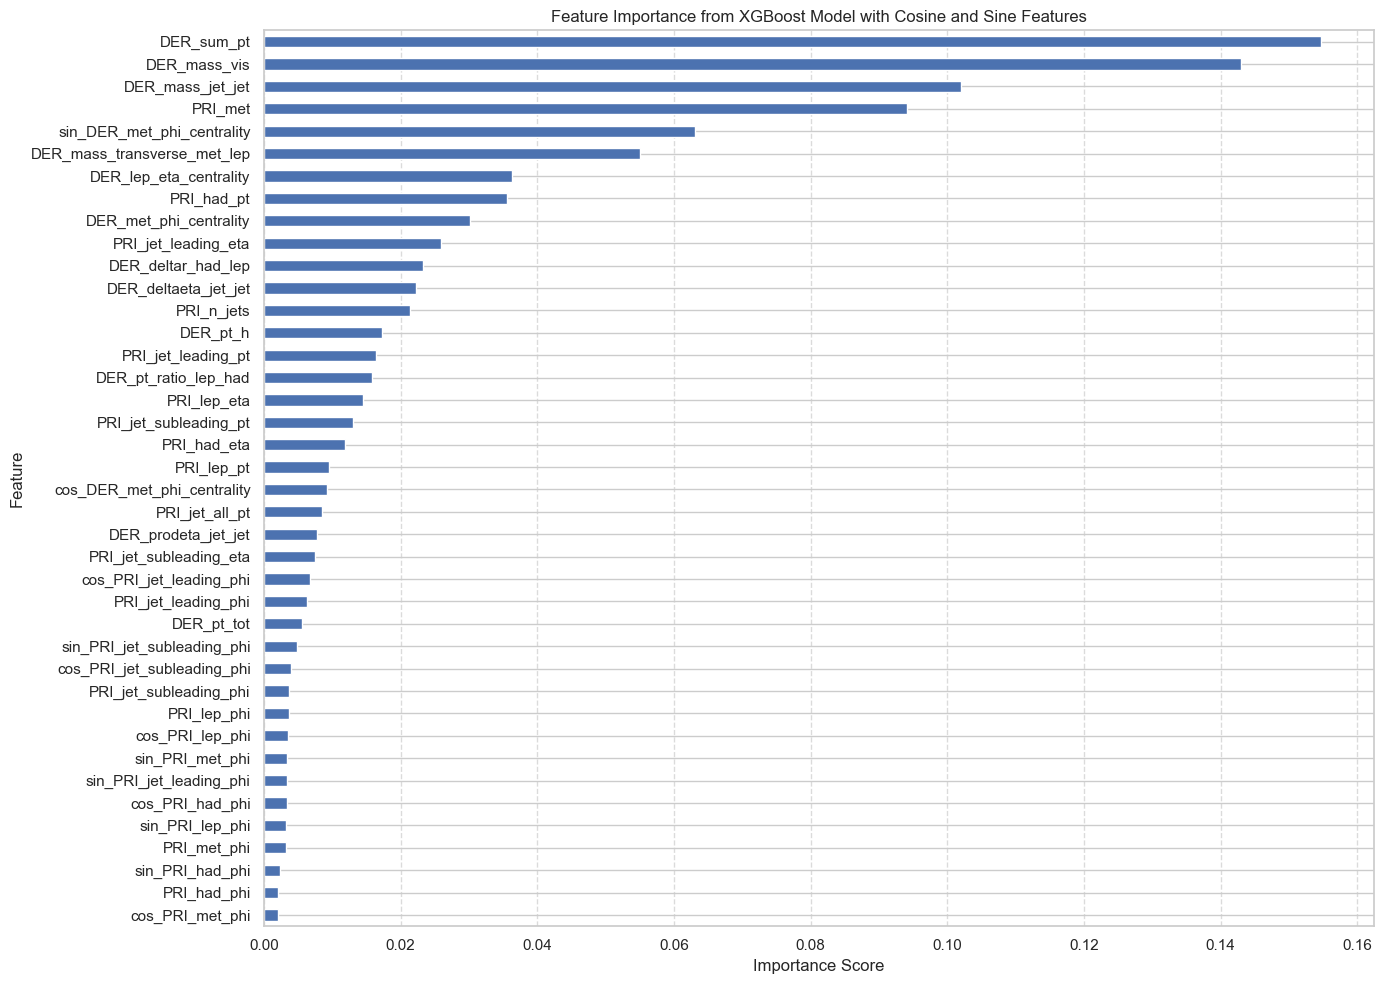

In [ ]:
import matplotlib.pyplot as plt

# Plotting the feature importances with extended features
plt.figure(
    figsize=(14, 10)
)  # Adjust figure size for better readability with more features
importance_series_extended_sorted.plot(kind="barh")
plt.title("Feature Importance from XGBoost Model with Cosine and Sine Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

### Analysis of Feature Importances with New Cosine and Sine Features

By comparing this new list of feature importances with the previous one (before adding `cos` and `sin` features), you can assess the impact of these transformations:

*   **New Features with High Importance**: If `cos_PRI_X_phi` or `sin_PRI_X_phi` features appear high in the sorted list, it indicates that the model found these transformed representations to be valuable for discrimination. This suggests that the circular nature of these angles was indeed important for the BDT.

*   **Changes in Original Phi Feature Importance**: Observe if the original `PRI_X_phi` features (e.g., `PRI_lep_phi`) have dropped in importance, remained stable, or disappeared from the top ranks. If their importance decreased while their `cos` and `sin` counterparts gained importance, it implies the transformed features are better capturing the underlying physics.

*   **Overall Model Impact**: The addition of these features might lead to a more robust model. This detailed view helps in feature selection and engineering for further model optimization.

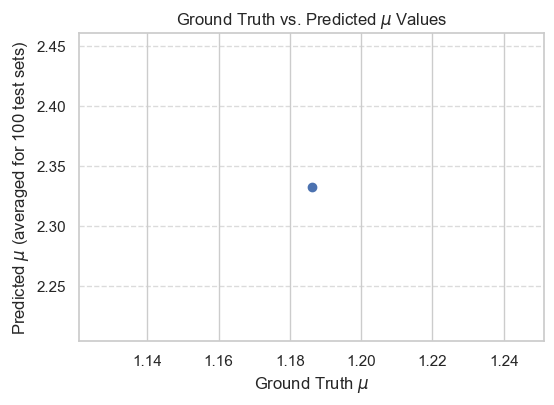

In [ ]:
from HiggsML.visualization import visualize_scatter

# Visualize scatter plot of ground truth mu and predicted mu
visualize_scatter(
    ingestion_result_dict=ingestion.results_dict,
    ground_truth_mus=test_settings["ground_truth_mus"],
)

Root Mean Square (RMS) of Biases for Each Feature:



PRI_had_pt                     0.025808
DER_deltaeta_jet_jet           0.021889
DER_pt_tot                     0.021159
DER_mass_transverse_met_lep    0.021025
PRI_met                        0.019556
DER_pt_ratio_lep_had           0.017205
DER_mass_vis                   0.016454
PRI_jet_all_pt                 0.011694
DER_pt_h                       0.011334
DER_mass_jet_jet               0.011293
DER_sum_pt                     0.010177
PRI_n_jets                     0.010021
DER_met_phi_centrality         0.010002
PRI_jet_leading_pt             0.007798
PRI_jet_subleading_pt          0.006703
DER_deltar_had_lep             0.003233
PRI_jet_subleading_eta         0.000440
PRI_jet_subleading_phi         0.000416
PRI_jet_leading_phi            0.000416
PRI_lep_pt                     0.000346
PRI_lep_eta                    0.000231
DER_lep_eta_centrality         0.000183
PRI_had_eta                    0.000173
DER_prodeta_jet_jet            0.000082
PRI_jet_leading_eta            0.000082


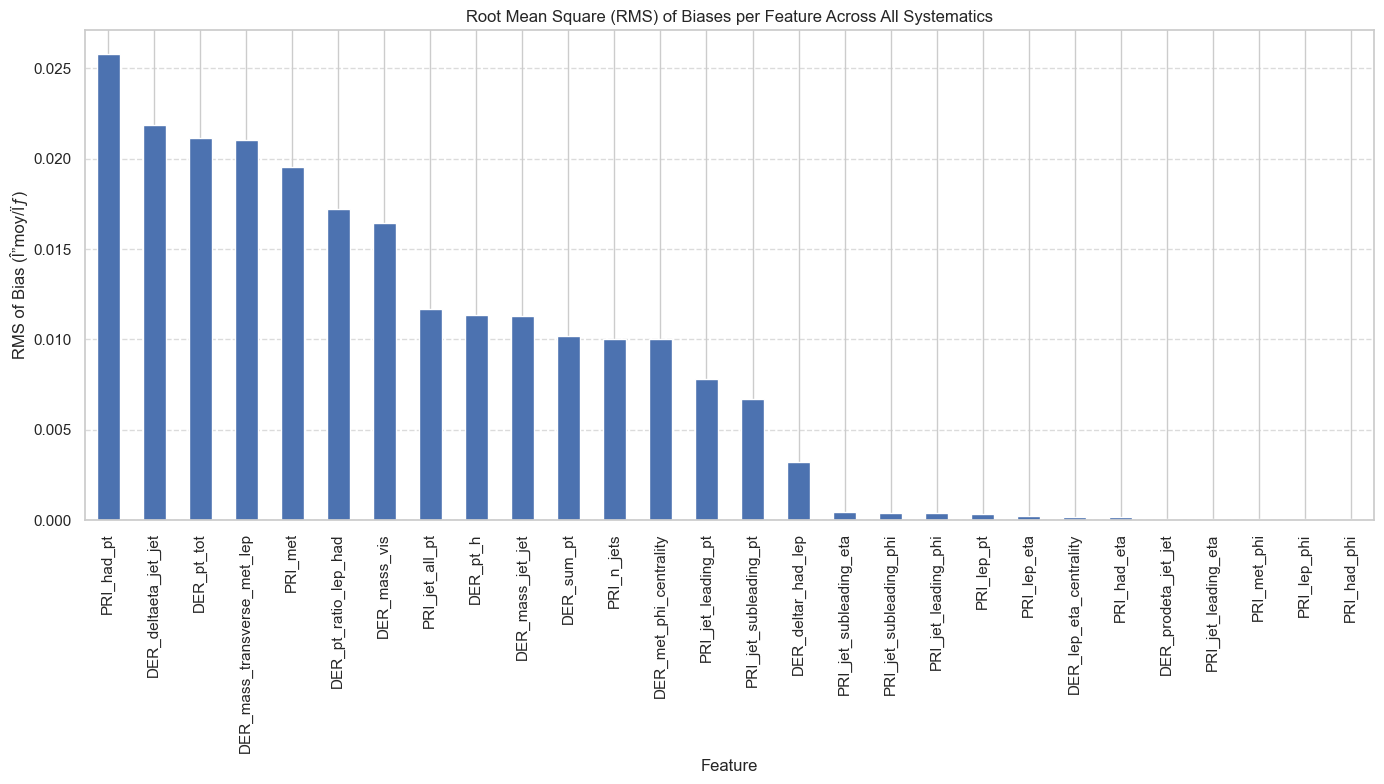

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Added for plotting

# Raw data from the notebook cell
raw_data = """
TES
feature,famille,TV,Î”moy/Ïƒ
PRI_had_pt,PRI,0.0295,0.0447
DER_mass_vis,DER,0.0258,0.0285
DER_pt_ratio_lep_had,DER,0.0206,-0.0298
DER_sum_pt,DER,0.0181,0.0062
DER_mass_transverse_met_lep,DER,0.017,-0.0234
PRI_met,PRI,0.0144,0.0114
DER_met_phi_centrality,DER,0.0102,-0.0121
PRI_jet_leading_pt,PRI,0.0032,-0.006
DER_deltar_had_lep,DER,0.0027,0.0056
PRI_jet_subleading_pt,PRI,0.0026,-0.004
PRI_met_phi,PRI,0.0019,1e-04
DER_pt_h,DER,0.0013,-0.0034
PRI_jet_subleading_phi,PRI,0.0013,-0.0004
DER_prodeta_jet_jet,DER,0.0012,-1e-04
PRI_jet_all_pt,PRI,0.0012,-0.0025
PRI_jet_subleading_eta,PRI,0.0011,-0.0003
DER_deltaeta_jet_jet,DER,0.001,0.001
DER_mass_jet_jet,DER,0.001,-0.0025
DER_pt_tot,DER,0.0009,-0.0023
PRI_n_jets,PRI,0.0009,-0.0014
DER_lep_eta_centrality,DER,0.0009,1e-04
PRI_jet_leading_eta,PRI,0.0008,1e-04
PRI_jet_leading_phi,PRI,0.0008,-0.0004
PRI_had_eta,PRI,0.0006,0.0003
PRI_lep_eta,PRI,0.0005,0.0004
PRI_lep_phi,PRI,0.0004,1e-04
PRI_lep_pt,PRI,0.0004,-0.0006
PRI_had_phi,PRI,0.0004,-1e-04


Soft_MET
feature,famille,TV,Î”moy/Ïƒ
DER_pt_tot,DER,0.0236,0.0359
DER_mass_transverse_met_lep,DER,0.0224,0.0278
PRI_met,PRI,0.0208,0.023
DER_pt_h,DER,0.0194,0.011
DER_met_phi_centrality,DER,0.0115,0.0027
PRI_met_phi,PRI,0.0032,0.0
PRI_lep_eta,PRI,0.0,0.0
DER_pt_ratio_lep_had,DER,0.0,0.0
DER_sum_pt,DER,0.0,0.0
DER_deltar_had_lep,DER,0.0,0.0
DER_prodeta_jet_jet,DER,0.0,0.0
DER_mass_jet_jet,DER,0.0,0.0
DER_deltaeta_jet_jet,DER,0.0,0.0
DER_mass_vis,DER,0.0,0.0
PRI_lep_pt,PRI,0.0,0.0
PRI_jet_all_pt,PRI,0.0,0.0
PRI_n_jets,PRI,0.0,0.0
PRI_jet_subleading_phi,PRI,0.0,0.0
PRI_jet_subleading_eta,PRI,0.0,0.0
PRI_jet_subleading_pt,PRI,0.0,0.0
PRI_jet_leading_phi,PRI,0.0,0.0
PRI_jet_leading_eta,PRI,0.0,0.0
PRI_jet_leading_pt,PRI,0.0,0.0
PRI_had_phi,PRI,0.0,0.0
PRI_had_eta,PRI,0.0,0.0
PRI_had_pt,PRI,0.0,0.0
PRI_lep_phi,PRI,0.0,0.0
DER_lep_eta_centrality,DER,0.0,0.0


JES
feature,famille,TV,Î”moy/Ïƒ
PRI_n_jets,PRI,0.0114,0.0173
PRI_jet_all_pt,PRI,0.0112,0.0201
DER_mass_jet_jet,DER,0.0104,0.0194
DER_sum_pt,DER,0.0096,0.0165
DER_met_phi_centrality,DER,0.0087,0.0121
PRI_jet_subleading_pt,PRI,0.0079,0.0109
PRI_met,PRI,0.0078,0.0221
DER_deltaeta_jet_jet,DER,0.0058,-0.0379
PRI_jet_leading_pt,PRI,0.0057,0.0121
DER_lep_eta_centrality,DER,0.0055,0.0003
DER_pt_h,DER,0.0052,0.0159
PRI_jet_subleading_eta,PRI,0.005,-0.0007
PRI_jet_leading_eta,PRI,0.0042,1e-04
DER_prodeta_jet_jet,DER,0.0041,1e-04
DER_pt_tot,DER,0.0038,-0.007
DER_mass_transverse_met_lep,DER,0.0018,0.0024
PRI_jet_subleading_phi,PRI,0.0015,0.0006
PRI_met_phi,PRI,0.0008,-0.0
PRI_jet_leading_phi,PRI,0.0008,-0.0006
PRI_lep_phi,PRI,0.0,0.0
DER_pt_ratio_lep_had,DER,0.0,0.0
PRI_had_pt,PRI,0.0,0.0
PRI_had_phi,PRI,0.0,0.0
DER_deltar_had_lep,DER,0.0,0.0
PRI_had_eta,PRI,0.0,0.0
DER_mass_vis,DER,0.0,0.0
PRI_lep_eta,PRI,0.0,0.0
PRI_lep_pt,PRI,0.0,0.0
"""

# Split the raw data into sections (TES, Soft_MET, JES)
# .strip() removes leading/trailing whitespace from the whole raw_data string.
# Filter out any empty strings that might result from the split if raw_data has extra newlines.
sections = [s for s in raw_data.strip().split("\n\n") if s.strip()]

all_features_biases = {}

for section_content in sections:
    # Each section_content now should be like 'TES\nfeature,famille,TV,Î”moy/Ïƒ\n...'
    # .strip() here ensures no leading/trailing whitespace for each section block itself
    lines = section_content.strip().split("\n")

    # The first line is the section name (e.g., 'TES', 'Soft_MET', 'JES')
    section_name_label = lines[0].strip()

    # The rest are the CSV data, starting with the header
    csv_data = "\n".join(lines[1:])

    # If csv_data is empty, skip this section (e.g., if a section was just a name with no data)
    if not csv_data.strip():
        print(f"Warning: Section '{section_name_label}' has no data. Skipping.")
        continue

    # Use pandas to read the CSV data for robust parsing
    # The header is implicitly the first line of csv_data
    df = pd.read_csv(io.StringIO(csv_data))

    # Extract feature and bias (Î”moy/Ïƒ) column
    # Handle potential encoding issues for 'Î”moy/Ïƒ'
    bias_cols = [
        col for col in df.columns if "moy" in col or "moy/s" in col or "Ïƒ" in col
    ]
    if not bias_cols:
        print(
            f"Warning: No 'Î”moy/Ïƒ' column found in section '{section_name_label}'. Columns: {df.columns}. Skipping."
        )
        continue

    bias_col_name = bias_cols[0]

    for index, row in df.iterrows():
        feature_name = row["feature"]
        bias_value = pd.to_numeric(row[bias_col_name], errors="coerce")

        if feature_name not in all_features_biases:
            all_features_biases[feature_name] = []
        if not pd.isna(bias_value):
            all_features_biases[feature_name].append(bias_value)

# Calculate RMS for each feature
rms_biases = {}
for feature, biases in all_features_biases.items():
    if biases:
        rms_biases[feature] = np.sqrt(np.mean(np.array(biases) ** 2))
    else:
        rms_biases[feature] = (
            np.nan
        )  # Or 0, depending on desired behavior for features with no biases

# Convert to a Pandas Series for better display and sorting
rms_series = pd.Series(rms_biases).sort_values(ascending=False)

print("Root Mean Square (RMS) of Biases for Each Feature:\n")
display(rms_series)

# Plotting the RMS of biases
plt.figure(figsize=(14, 8))
rms_series.plot(kind="bar")
plt.title("Root Mean Square (RMS) of Biases per Feature Across All Systematics")
plt.xlabel("Feature")
plt.ylabel("RMS of Bias (Î”moy/Ïƒ)")
plt.xticks(rotation=90)  # Rotate labels for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

### RMS of Biases vs. Feature Importance

This plot visualizes the relationship between the Root Mean Square (RMS) of biases for each feature (indicating its sensitivity to systematics) and its importance as determined by the XGBoost model.

*   **High Importance, Low RMS Bias**: Features in this region are very important for the model and relatively stable against systematic variations, making them highly desirable.
*   **High Importance, High RMS Bias**: These features are crucial for the model but are also significantly affected by systematics. Their use requires careful consideration of uncertainties.
*   **Low Importance, Low RMS Bias**: These features are stable but not very discriminatory.
*   **Low Importance, High RMS Bias**: These features are neither very important nor stable, and might be considered for removal or further investigation.


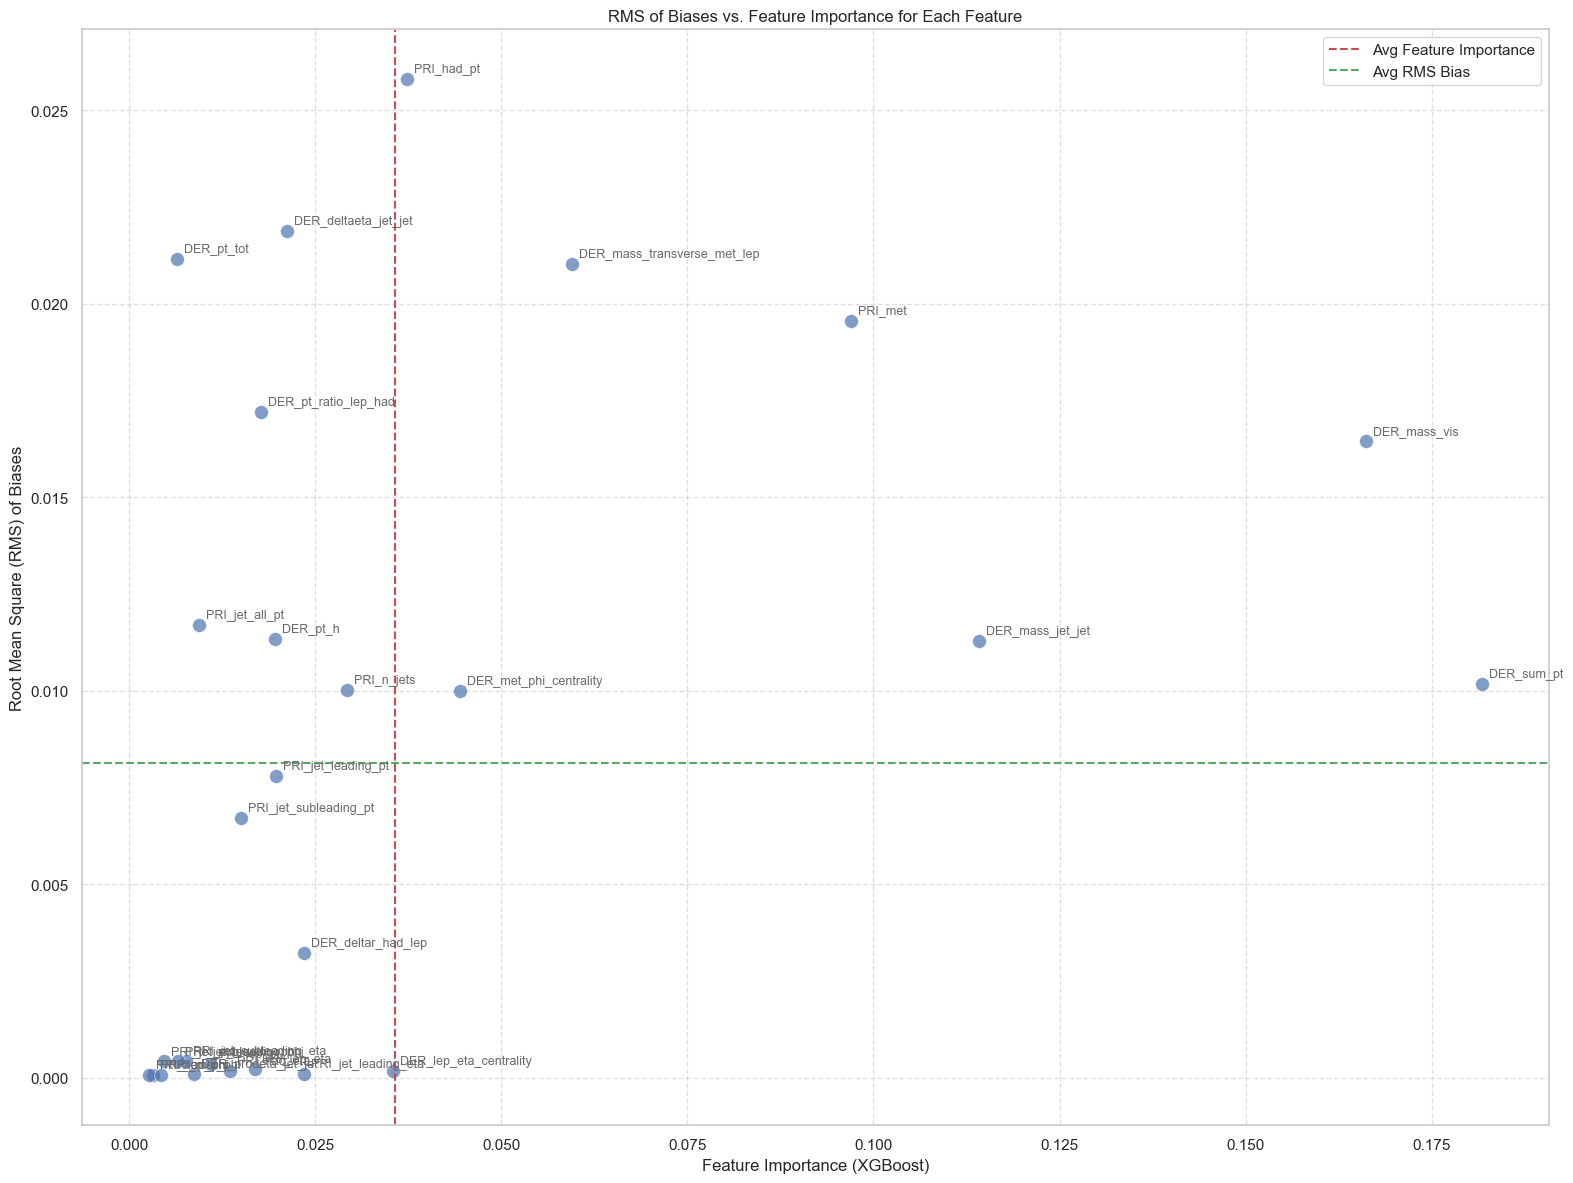

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure both series are aligned by feature name (index)
# It's good practice to reindex to ensure they have the same order and features
common_features = list(set(rms_series.index) & set(importance_series_sorted.index))

# Filter and align the series to common features
rms_aligned = rms_series[common_features]
importance_aligned = importance_series_sorted[common_features]

# Create a DataFrame for plotting
comparison_df = pd.DataFrame(
    {"RMS_Bias": rms_aligned, "Feature_Importance": importance_aligned}
).reindex(
    importance_aligned.index
)  # Reindex to keep the sorting by importance as a primary view

plt.figure(figsize=(16, 12))

# Create the scatter plot
scatter = plt.scatter(
    comparison_df["Feature_Importance"],
    comparison_df["RMS_Bias"],
    s=100,  # size of points
    alpha=0.7,
    edgecolors="w",
    linewidth=0.5,
)

# Add annotations for each point
for i, feature_name in enumerate(comparison_df.index):
    plt.annotate(
        feature_name,
        (
            comparison_df["Feature_Importance"].iloc[i],
            comparison_df["RMS_Bias"].iloc[i],
        ),
        textcoords="offset points",  # how to position the text
        xytext=(5, 5),  # distance from text to points (x,y)
        ha="left",  # horizontal alignment
        fontsize=9,  # font size
        color="dimgray",
    )

plt.title("RMS of Biases vs. Feature Importance for Each Feature")
plt.xlabel("Feature Importance (XGBoost)")
plt.ylabel("Root Mean Square (RMS) of Biases")
plt.grid(True, linestyle="--", alpha=0.6)
plt.axvline(
    x=comparison_df["Feature_Importance"].mean(),
    color="r",
    linestyle="--",
    label="Avg Feature Importance",
)
plt.axhline(
    y=comparison_df["RMS_Bias"].mean(), color="g", linestyle="--", label="Avg RMS Bias"
)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
!python -m HiggsML.score --prediction $output_dir --output $output_dir

############################################
### Scoring Program
############################################

c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission\test_settings.json
c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission
[✔]
rmse     1.7604
mae     2.0342
interval     0.5175
coverage     0.0
quantiles_score     -13.0531
ingestion_duration     0

----------------------------------------------
[✔] Scoring Program executed successfully!
----------------------------------------------




2026-06-03 14:47:31,773 - HiggsML.score        - INFO     - Reading ingestion duration from c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission\ingestion_duration.json
2026-06-03 14:47:31,773 - HiggsML.score        - WARNING  - File c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission\ingestion_duration.json not found. Setting ingestion duration to 0.
2026-06-03 14:47:31,776 - HiggsML.score        - INFO     - Read ingestion results from c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission
2026-06-03 14:47:31,778 - HiggsML.score        - INFO     - Computing scores
2026-06-03 14:47:35,055 - HiggsML.score        - INFO     - Writing scores to c:\Users\ulyss\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission\scores.json


In [25]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


class BoostedDecisionTreeScalePosWeight:
    def __init__(
        self,
        n_estimators=1500,
        max_depth=6,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=6,
        gamma=0,
        tree_method="hist",
        random_state=31415,
        early_stopping_rounds=25,
        scale_factor=1.0,
    ):

        self.scale_factor = scale_factor

        self.model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            gamma=gamma,
            tree_method=tree_method,
            random_state=random_state,
            early_stopping_rounds=early_stopping_rounds,
        )

    def fit(self, train_data, labels, weights=None):
        sum_w_background = np.sum(weights[labels == 0])
        sum_w_signal = np.sum(weights[labels == 1])
        ratio = (sum_w_background / sum_w_signal) * self.scale_factor

        self.model.set_params(scale_pos_weight=ratio)

        print(f"[INFO] scale_pos_weight configuré à {ratio:.2f}")

        X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
            train_data, labels, weights, test_size=0.2, random_state=42, stratify=labels
        )

        self.model.fit(
            X_tr,
            y_tr,
            sample_weight=w_tr,
            eval_set=[(X_val, y_val)],
            sample_weight_eval_set=[w_val],
            verbose=False,
        )

    def predict(self, test_data):
        return self.model.predict_proba(test_data)[:, 1]

[*] Chargement des données...
[*] Entraînement du BDT...
[INFO] scale_pos_weight configuré à 155.41
[*] Entraînement terminé.
[*] Parsing biases and calcul RMS...
[*] RMS biases calculés.
[✓] Saved bdt_feature_importances_horizontal.png


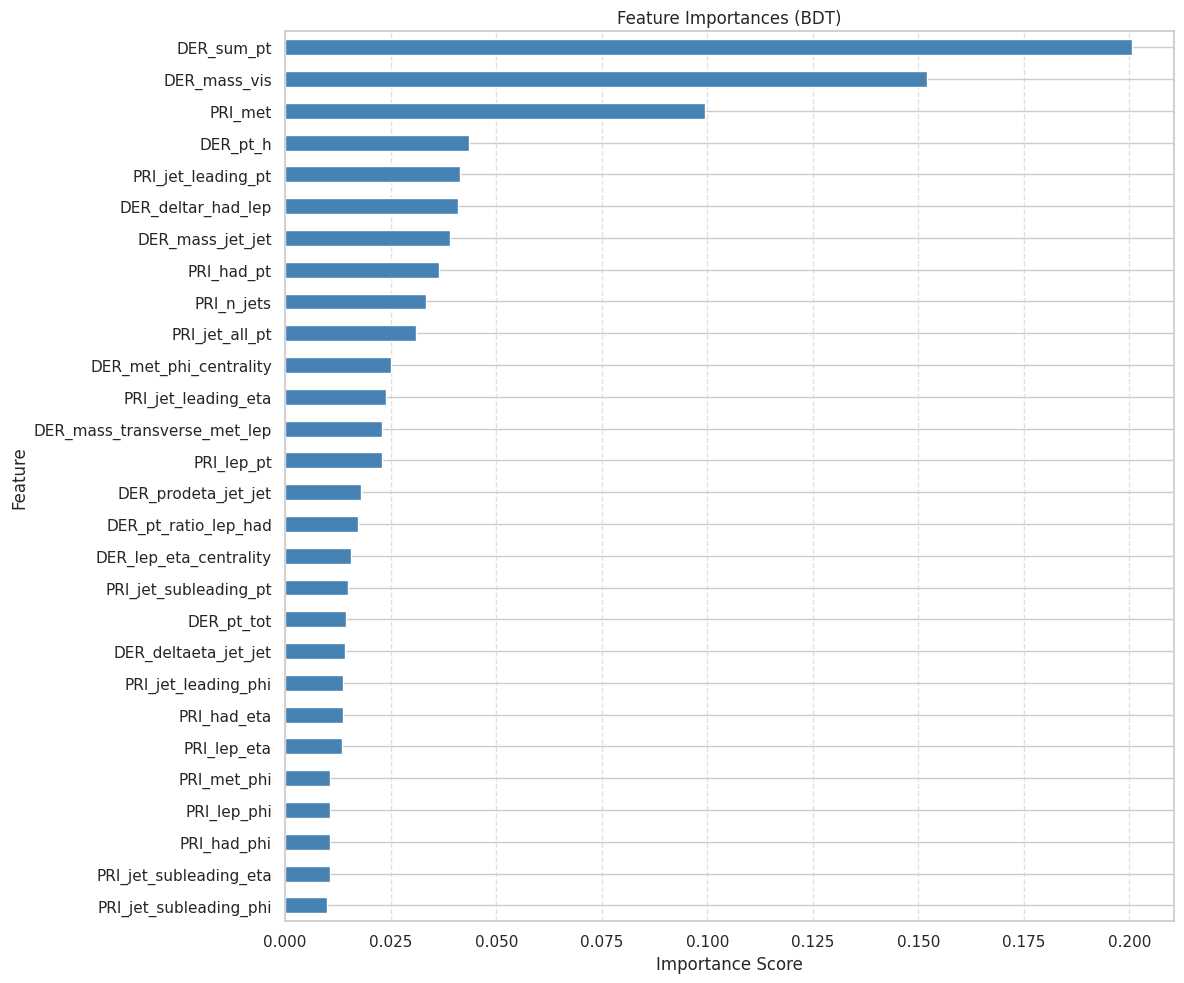

[✓] Saved bdt_bias_vs_importance.png


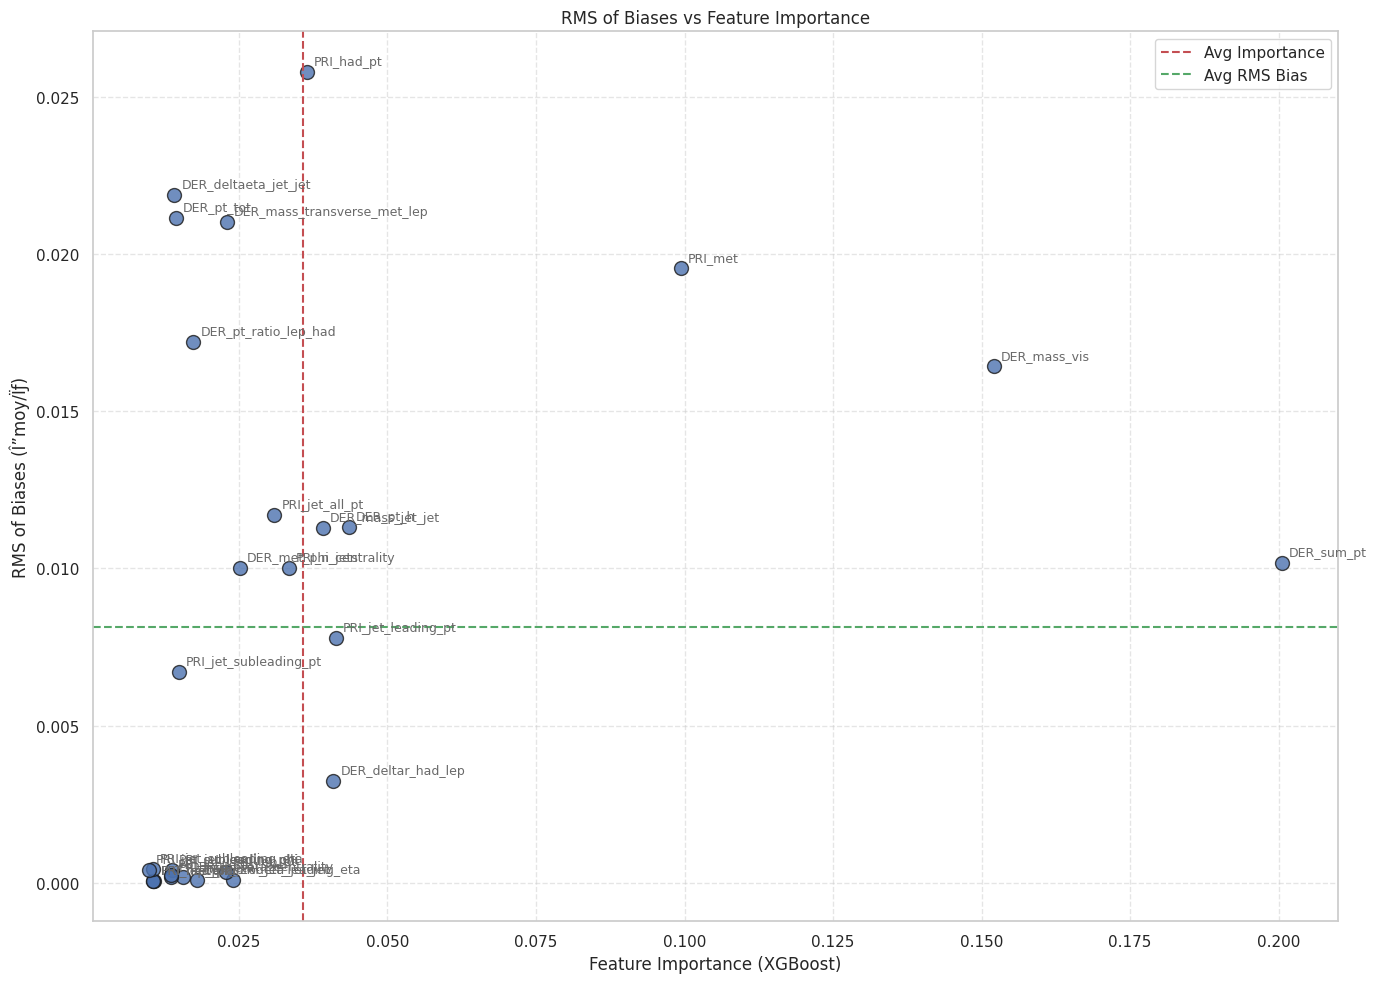

[✓] Saved bdt_importance_bias_comparison.csv


In [27]:
"""
Script: plot_bdt_bias_vs_importance.py
- Entraine le BDT (même config que main.py)
- Extrait les feature importances
- Parse le raw_data (biais système) fourni et calcule RMS par feature
- Trace : 1) horizontal bar chart des importances 2) scatter RMS(biais) vs importance
- Sauvegarde les résultats (PNG + CSV)
"""

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from HiggsML.datasets import download_dataset
from sklearn.model_selection import train_test_split


def parse_raw_biases(raw_data: str):
    sections = [s for s in raw_data.strip().split("\n\n") if s.strip()]
    all_features_biases = {}
    for section_content in sections:
        lines = section_content.strip().split("\n")
        section_name_label = lines[0].strip()
        csv_data = "\n".join(lines[1:])
        if not csv_data.strip():
            continue
        df = pd.read_csv(io.StringIO(csv_data))
        bias_cols = [
            col
            for col in df.columns
            if "moy" in col or "moy/s" in col or "Ï" in col or "Î" in col
        ]
        if not bias_cols:
            continue
        bias_col_name = bias_cols[0]
        for _, row in df.iterrows():
            feature_name = row["feature"]
            bias_value = pd.to_numeric(row[bias_col_name], errors="coerce")
            if feature_name not in all_features_biases:
                all_features_biases[feature_name] = []
            if not pd.isna(bias_value):
                all_features_biases[feature_name].append(bias_value)
    rms_biases = {}
    for feature, biases in all_features_biases.items():
        if biases:
            rms_biases[feature] = np.sqrt(np.mean(np.array(biases) ** 2))
        else:
            rms_biases[feature] = np.nan
    return pd.Series(rms_biases)


def main():
    print("[*] Chargement des données...")
    data = download_dataset("blackSwan_data")
    data.load_train_set()
    data_set = data.get_train_set()

    # Préparer features, labels, weights
    features_df = data_set.drop(columns=["labels", "weights", "detailed_labels"])
    feature_names = features_df.columns.tolist()
    labels = data_set["labels"]
    weights = data_set["weights"]

    # Split comme dans main.py
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        features_df, labels, weights, test_size=0.3, random_state=42, stratify=labels
    )

    # Entraîner le BDT (mêmes hyperparamètres que main.py)
    print("[*] Entraînement du BDT...")
    bdt = BoostedDecisionTreeScalePosWeight(
        n_estimators=1000,
        max_depth=9,
        learning_rate=0.08501869815505453,
        subsample=1.0,
        colsample_bytree=0.6,
        min_child_weight=1,
        tree_method="hist",
        random_state=31415,
        early_stopping_rounds=15,
    )
    bdt.fit(X_train, y_train, w_train)
    print("[*] Entraînement terminé.")

    # Extraire importances
    if not hasattr(bdt.model, "feature_importances_"):
        raise AttributeError(
            "Le modèle interne XGBoost ne fournit pas feature_importances_."
        )
    importances = bdt.model.feature_importances_
    importance_series = pd.Series(importances, index=feature_names)
    importance_sorted = importance_series.sort_values(ascending=False)

    # Raw bias data (copié depuis votre exemple)
    raw_data = """
TES
feature,famille,TV,Î”moy/Ïƒ
PRI_had_pt,PRI,0.0295,0.0447
DER_mass_vis,DER,0.0258,0.0285
DER_pt_ratio_lep_had,DER,0.0206,-0.0298
DER_sum_pt,DER,0.0181,0.0062
DER_mass_transverse_met_lep,DER,0.017,-0.0234
PRI_met,PRI,0.0144,0.0114
DER_met_phi_centrality,DER,0.0102,-0.0121
PRI_jet_leading_pt,PRI,0.0032,-0.006
DER_deltar_had_lep,DER,0.0027,0.0056
PRI_jet_subleading_pt,PRI,0.0026,-0.004
PRI_met_phi,PRI,0.0019,1e-04
DER_pt_h,DER,0.0013,-0.0034
PRI_jet_subleading_phi,PRI,0.0013,-0.0004
DER_prodeta_jet_jet,DER,0.0012,-1e-04
PRI_jet_all_pt,PRI,0.0012,-0.0025
PRI_jet_subleading_eta,PRI,0.0011,-0.0003
DER_deltaeta_jet_jet,DER,0.001,0.001
DER_mass_jet_jet,DER,0.001,-0.0025
DER_pt_tot,DER,0.0009,-0.0023
PRI_n_jets,PRI,0.0009,-0.0014
DER_lep_eta_centrality,DER,0.0009,1e-04
PRI_jet_leading_eta,PRI,0.0008,1e-04
PRI_jet_leading_phi,PRI,0.0008,-0.0004
PRI_had_eta,PRI,0.0006,0.0003
PRI_lep_eta,PRI,0.0005,0.0004
PRI_lep_phi,PRI,0.0004,1e-04
PRI_lep_pt,PRI,0.0004,-0.0006
PRI_had_phi,PRI,0.0004,-1e-04


Soft_MET
feature,famille,TV,Î”moy/Ïƒ
DER_pt_tot,DER,0.0236,0.0359
DER_mass_transverse_met_lep,DER,0.0224,0.0278
PRI_met,PRI,0.0208,0.023
DER_pt_h,DER,0.0194,0.011
DER_met_phi_centrality,DER,0.0115,0.0027
PRI_met_phi,PRI,0.0032,0.0
PRI_lep_eta,PRI,0.0,0.0
DER_pt_ratio_lep_had,DER,0.0,0.0
DER_sum_pt,DER,0.0,0.0
DER_deltar_had_lep,DER,0.0,0.0
DER_prodeta_jet_jet,DER,0.0,0.0
DER_mass_jet_jet,DER,0.0,0.0
DER_deltaeta_jet_jet,DER,0.0,0.0
DER_mass_vis,DER,0.0,0.0
PRI_lep_pt,PRI,0.0,0.0
PRI_jet_all_pt,PRI,0.0,0.0
PRI_n_jets,PRI,0.0,0.0
PRI_jet_subleading_phi,PRI,0.0,0.0
PRI_jet_subleading_eta,PRI,0.0,0.0
PRI_jet_subleading_pt,PRI,0.0,0.0
PRI_jet_leading_phi,PRI,0.0,0.0
PRI_jet_leading_eta,PRI,0.0,0.0
PRI_jet_leading_pt,PRI,0.0,0.0
PRI_had_phi,PRI,0.0,0.0
PRI_had_eta,PRI,0.0,0.0
PRI_had_pt,PRI,0.0,0.0
PRI_lep_phi,PRI,0.0,0.0
DER_lep_eta_centrality,DER,0.0,0.0


JES
feature,famille,TV,Î”moy/Ïƒ
PRI_n_jets,PRI,0.0114,0.0173
PRI_jet_all_pt,PRI,0.0112,0.0201
DER_mass_jet_jet,DER,0.0104,0.0194
DER_sum_pt,DER,0.0096,0.0165
DER_met_phi_centrality,DER,0.0087,0.0121
PRI_jet_subleading_pt,PRI,0.0079,0.0109
PRI_met,PRI,0.0078,0.0221
DER_deltaeta_jet_jet,DER,0.0058,-0.0379
PRI_jet_leading_pt,PRI,0.0057,0.0121
DER_lep_eta_centrality,DER,0.0055,0.0003
DER_pt_h,DER,0.0052,0.0159
PRI_jet_subleading_eta,PRI,0.005,-0.0007
PRI_jet_leading_eta,PRI,0.0042,1e-04
DER_prodeta_jet_jet,DER,0.0041,1e-04
DER_pt_tot,DER,0.0038,-0.007
DER_mass_transverse_met_lep,DER,0.0018,0.0024
PRI_jet_subleading_phi,PRI,0.0015,0.0006
PRI_met_phi,PRI,0.0008,-0.0
PRI_jet_leading_phi,PRI,0.0008,-0.0006
PRI_lep_phi,PRI,0.0,0.0
DER_pt_ratio_lep_had,DER,0.0,0.0
PRI_had_pt,PRI,0.0,0.0
PRI_had_phi,PRI,0.0,0.0
DER_deltar_had_lep,DER,0.0,0.0
PRI_had_eta,PRI,0.0,0.0
DER_mass_vis,DER,0.0,0.0
PRI_lep_eta,PRI,0.0,0.0
PRI_lep_pt,PRI,0.0,0.0
"""

    # Parse RMS biases
    print("[*] Parsing biases and calcul RMS...")
    rms_series = parse_raw_biases(raw_data).sort_values(ascending=False)
    print("[*] RMS biases calculés.")

    # Align features present in both importance and rms
    common = list(set(importance_sorted.index) & set(rms_series.index))
    if not common:
        raise RuntimeError("Aucune feature commune entre importances et biais.")

    importance_aligned = importance_sorted[common]
    rms_aligned = rms_series[common]

    # Build DataFrame and sort by importance
    comp_df = pd.DataFrame(
        {"Feature_Importance": importance_aligned, "RMS_Bias": rms_aligned}
    ).dropna()
    comp_df = comp_df.sort_values(by="Feature_Importance", ascending=False)

    # Plot horizontal bar chart (importances)
    plt.figure(figsize=(12, 10))
    comp_df["Feature_Importance"].sort_values(ascending=True).plot(
        kind="barh", color="steelblue"
    )
    plt.title("Feature Importances (BDT)")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("bdt_feature_importances_horizontal.png", dpi=300)
    print("[✓] Saved bdt_feature_importances_horizontal.png")
    plt.show()

    # Plot scatter: importance (x) vs RMS bias (y)
    plt.figure(figsize=(14, 10))
    plt.scatter(
        comp_df["Feature_Importance"],
        comp_df["RMS_Bias"],
        s=100,
        alpha=0.8,
        edgecolors="k",
    )
    for i, feat in enumerate(comp_df.index):
        plt.annotate(
            feat,
            (comp_df["Feature_Importance"].iloc[i], comp_df["RMS_Bias"].iloc[i]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            color="dimgray",
        )
    plt.xlabel("Feature Importance (XGBoost)")
    plt.ylabel("RMS of Biases (Î”moy/Ïƒ)")
    plt.title("RMS of Biases vs Feature Importance")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.axvline(
        x=comp_df["Feature_Importance"].mean(),
        color="r",
        linestyle="--",
        label="Avg Importance",
    )
    plt.axhline(
        y=comp_df["RMS_Bias"].mean(), color="g", linestyle="--", label="Avg RMS Bias"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig("bdt_bias_vs_importance.png", dpi=300)
    print("[✓] Saved bdt_bias_vs_importance.png")
    plt.show()

    # Save CSV
    comp_df.to_csv("bdt_importance_bias_comparison.csv")
    print("[✓] Saved bdt_importance_bias_comparison.csv")


if __name__ == "__main__":
    main()

# Systematics effect


Text(0.5, 1.0, 'PRI_had_pt — sensible au JES')

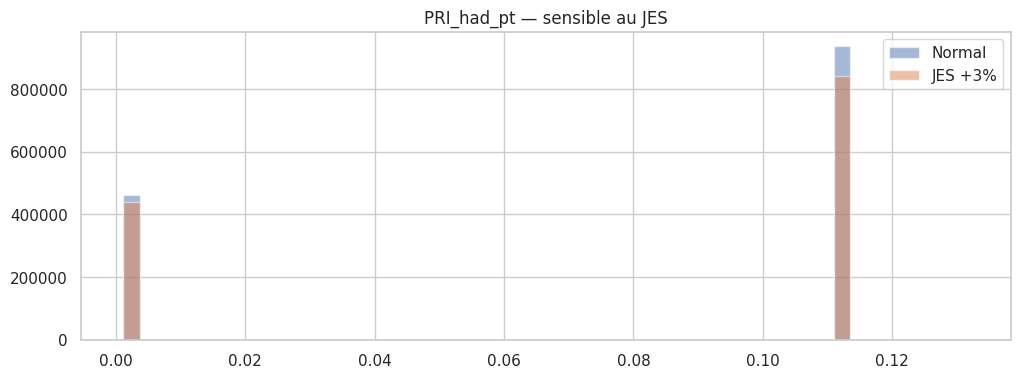

In [28]:
from HiggsML.systematics import systematics
from HiggsML.datasets import download_dataset

# Charger les données normales
data_normal = download_dataset("blackSwan_data")  # votre dataset de base

data_normal.load_train_set()
data_train = data_normal.get_train_set()

# Appliquer une variation TES de 3%
data_with_JES = systematics(data_train, jes=0.97)  # -3% sur l'énergie des taus

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))


plt.hist(data_train["weights"], bins=50, alpha=0.5, label="Normal")
plt.hist(data_with_JES["weights"], bins=50, alpha=0.5, label="JES +3%")
plt.legend()
plt.title("PRI_had_pt — sensible au JES")

In [29]:
# To calculate the score, we need to import the compute_mu function
from statistical_analysis import compute_mu

# Get the feature columns by excluding non-feature columns
non_feature_cols = ["weights", "labels", "detailed_labels"]
feature_cols = [col for col in data_train.columns if col not in non_feature_cols]

print("-- Scores for Normal Data (data_train) ---")
# Prepare input for prediction for data_train
predict_input_train = {
    "data": data_train[feature_cols],
    "weights": data_train["weights"],
}
# Get predictions (scores) from the model. This dictionary already contains mu_hat etc.
mu_results_train = ingestion.model.predict(predict_input_train)
print(mu_results_train)

print("\n--- Scores for JES-varied Data (data_with_JES, JES=0.97) ---")
# Prepare input for prediction for data_with_JES
predict_input_jes = {
    "data": data_with_JES[feature_cols],
    "weights": data_with_JES["weights"],
}
# Get predictions (scores) from the model. This dictionary already contains mu_hat etc.
mu_results_jes = ingestion.model.predict(predict_input_jes)
print(mu_results_jes)

-- Scores for Normal Data (data_train) ---
Test Results:  {'mu_hat': np.float64(4.24857014170735), 'del_mu_stat': np.float64(0.27570018946513786), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27570018946513786)}
{'mu_hat': np.float64(4.24857014170735), 'delta_mu_hat': np.float64(0.27570018946513786), 'p16': np.float64(3.972869952242212), 'p84': np.float64(4.524270331172488)}

--- Scores for JES-varied Data (data_with_JES, JES=0.97) ---
Test Results:  {'mu_hat': np.float64(0.4500524905214704), 'del_mu_stat': np.float64(0.27570018946513786), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27570018946513786)}
{'mu_hat': np.float64(0.4500524905214704), 'delta_mu_hat': np.float64(0.27570018946513786), 'p16': np.float64(0.17435230105633254), 'p84': np.float64(0.7257526799866083)}



--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


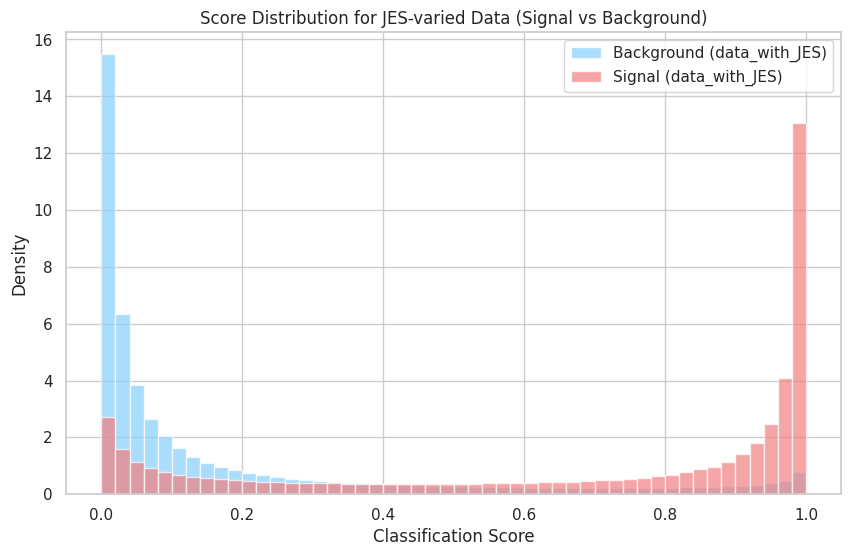


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


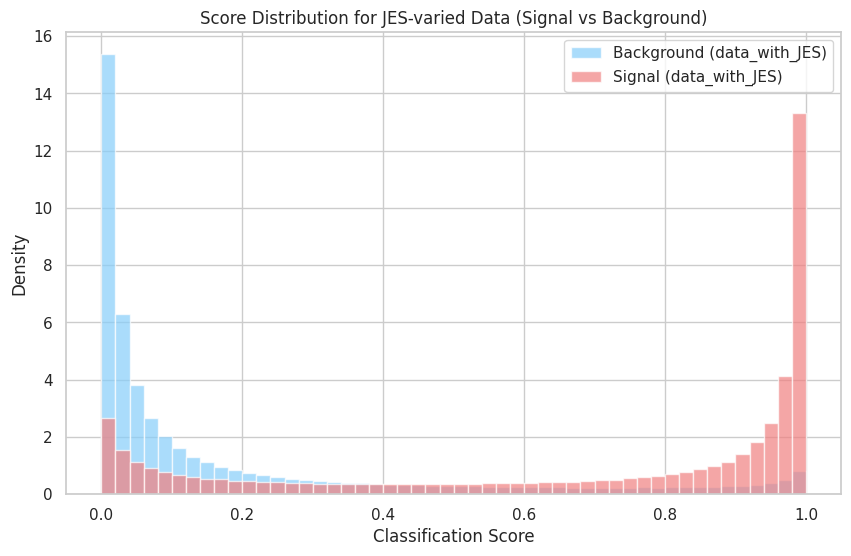


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


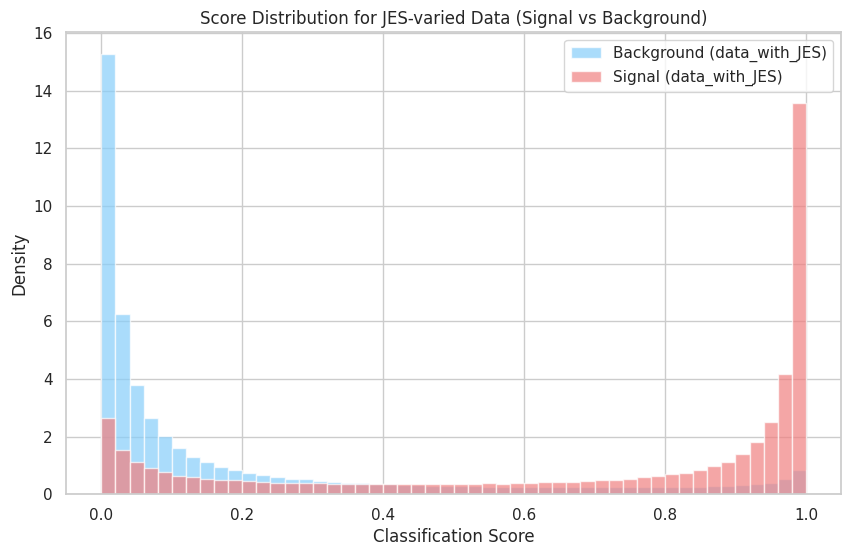


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


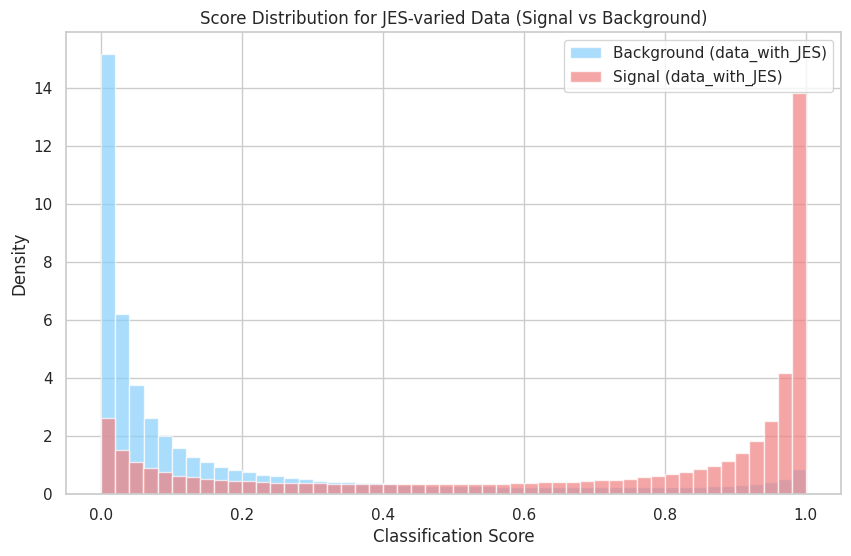


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


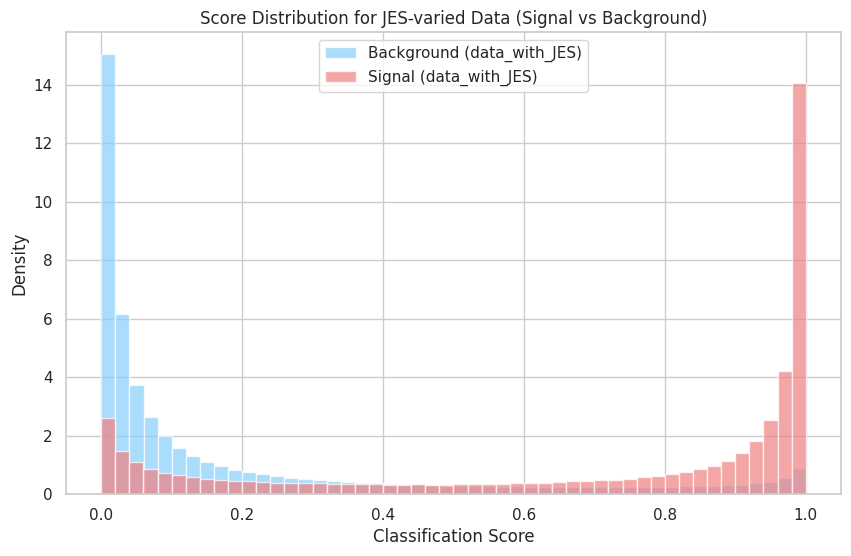

In [30]:
L = np.linspace(0.97, 1.03, 5)
for jesval in L:
    data_with_JES = systematics(data_train, jes=jesval)  # variation de jes
    import matplotlib.pyplot as plt

    print("\n--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---")

    # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
    non_feature_cols = ["weights", "labels", "detailed_labels"]
    feature_cols = [col for col in data_with_JES.columns if col not in non_feature_cols]

    # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
    # Assuming predict returns probabilities/scores directly.
    raw_scores_jes = ingestion.model.model.predict(data_with_JES[feature_cols])

    signal_scores_jes = raw_scores_jes[data_with_JES["labels"] == 1]
    background_scores_jes = raw_scores_jes[data_with_JES["labels"] == 0]

    # Plot the distributions for data_with_JES
    plt.figure(figsize=(10, 6))
    plt.hist(
        background_scores_jes,
        bins=50,
        alpha=0.7,
        label="Background (data_with_JES)",
        color="lightskyblue",
        density=True,
    )
    plt.hist(
        signal_scores_jes,
        bins=50,
        alpha=0.7,
        label="Signal (data_with_JES)",
        color="lightcoral",
        density=True,
    )
    plt.title("Score Distribution for JES-varied Data (Signal vs Background)")
    plt.xlabel("Classification Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
def varpar(par, parnormal, listevalpar, intervalscore):
    c = intervalscore[0]
    d = intervalscore[1]
    kwargs = {par: parnormal}
    data_with_PAR = systematics(data_train, **kwargs)  # variation du paramètre

    # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
    non_feature_cols = ["weights", "labels", "detailed_labels"]
    feature_cols = [col for col in data_with_PAR.columns if col not in non_feature_cols]

    # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
    # Assuming predict returns probabilities/scores directly.
    raw_scores_par = ingestion.model.model.predict(data_with_PAR[feature_cols])

    signal_scores_par = raw_scores_par[data_with_PAR["labels"] == 1]
    background_scores_par = raw_scores_par[data_with_PAR["labels"] == 0]

    s0 = 0
    b0 = 0
    for i in range(len(raw_scores_par)):
        if (
            data_with_PAR["labels"][i] == 1
            and raw_scores_par[i] > c
            and raw_scores_par[i] < d
        ):
            s0 = s0 + data_with_PAR["weights"][i]
        if (
            data_with_PAR["labels"][i] == 0
            and raw_scores_par[i] > c
            and raw_scores_par[i] < d
        ):
            b0 = b0 + data_with_PAR["weights"][i]

    liste_delta_s = []
    liste_delta_b = []
    L = listevalpar
    for parval in L:
        kwargs = {par: parval}
        data_with_PAR = systematics(data_train, **kwargs)  # variation du paramètre

        # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
        non_feature_cols = ["weights", "labels", "detailed_labels"]
        feature_cols = [
            col for col in data_with_PAR.columns if col not in non_feature_cols
        ]

        # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
        # Assuming predict returns probabilities/scores directly.
        raw_scores_par = ingestion.model.model.predict(data_with_PAR[feature_cols])

        signal_scores_tes = raw_scores_par[data_with_PAR["labels"] == 1]
        background_scores_tes = raw_scores_par[data_with_PAR["labels"] == 0]

        s = 0
        b = 0
        for i in range(len(raw_scores_par)):
            if (
                data_with_PAR["labels"][i] == 1
                and raw_scores_par[i] > c
                and raw_scores_par[i] < d
            ):
                s = s + data_with_PAR["weights"][i]
            if (
                data_with_PAR["labels"][i] == 0
                and raw_scores_par[i] > c
                and raw_scores_par[i] < d
            ):
                b = b + data_with_PAR["weights"][i]
        liste_delta_s.append(s - s0)
        liste_delta_b.append(b - b0)

    return liste_delta_s, liste_delta_b

In [ ]:
liste_delta_s2, liste_delta_b2 = varpar("tes", 1, np.linspace(0.9, 1.1, 10), [0.7, 0.8])
liste_delta_s0, liste_delta_b0 = varpar("tes", 1, np.linspace(0.9, 1.1, 10), [0.9, 1])
liste_delta_s1, liste_delta_b1 = varpar("tes", 1, np.linspace(0.9, 1.1, 10), [0.8, 0.9])

In [32]:
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_s0, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_s1, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_s2, marker="o")
plt.title("Variation du signal en fonction de tes pour trois bins de scores")
plt.show()
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_b0, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_b1, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_b2, marker="o")
plt.title("Variation du bruit en fonction de tes pour trois bins de scores")
plt.show()

NameError: name 'liste_delta_s0' is not defined

In [ ]:
liste_delta_s2, liste_delta_b2 = varpar("jes", 1, np.linspace(0.9, 1.1, 10), [0.7, 0.8])
liste_delta_s1, liste_delta_b1 = varpar("jes", 1, np.linspace(0.9, 1.1, 10), [0.8, 0.9])
liste_delta_s0, liste_delta_b0 = varpar("jes", 1, np.linspace(0.9, 1.1, 10), [0.9, 1])

plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_s0, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_s1, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_s2, marker="o")
plt.title("Variation du signal en fonction de jes pour trois bins de scores")
plt.show()
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_b0, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_b1, marker="o")
plt.plot(np.linspace(0.9, 1.1, 10), liste_delta_b2, marker="o")
plt.title("Variation du bruit en fonction de jes pour trois bins de scores")
plt.show()

In [ ]:
l = np.linspace(0.7, 1, 11)
a = [[] for k in range(0, 10)]
b = [[] for k in range(0, 10)]
for i in range(len(l) - 1):
    a[i], b[i] = varpar("jes", 1, np.linspace(0.9, 1.1, 10), [l[i], l[i + 1]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Paramètres des bins et des variations
score_bins_centers = (l[:-1] + l[1:]) / 2
jes_values = np.linspace(0.9, 1.1, 10)
cmap = plt.cm.get_cmap("coolwarm", len(jes_values))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot pour a[i] (Signal)
for j in range(len(jes_values)):
    # On extrait le j-ème élément de chaque sous-liste a[i]
    weights_per_bin_a = [a[i][j] for i in range(len(a))]
    ax1.plot(
        score_bins_centers,
        weights_per_bin_a,
        marker="o",
        color=cmap(j),
        label=f"jes={jes_values[j]:.2f}",
    )

ax1.set_title("Poids du Signal (a) par Bin de Score")
ax1.set_xlabel("Score moyen du bin")
ax1.set_ylabel("Variation du poids (s - s0)")
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot pour b[i] (Bruit)
for j in range(len(jes_values)):
    # On extrait le j-ème élément de chaque sous-liste b[i]
    weights_per_bin_b = [b[i][j] for i in range(len(b))]
    ax2.plot(
        score_bins_centers,
        weights_per_bin_b,
        marker="o",
        color=cmap(j),
        label=f"jes={jes_values[j]:.2f}",
    )

ax2.set_title("Poids du Bruit (b) par Bin de Score")
ax2.set_xlabel("Score moyen du bin")
ax2.set_ylabel("Variation du poids (b - b0)")
ax2.grid(True, linestyle="--", alpha=0.6)

# Légende unique pour la figure
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Valeurs JES")
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()